# Final Project

## Preperation Work

In [1]:
from cProfile import label
from math import gamma

# library import
import pandas as pd
import numpy as np
from chess import PIECE_TYPES
from chess.svg import board
import matplotlib.pyplot as plt
from typing import List, Tuple

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neural_network import MLPClassifier

# chess library
import chess
import chess.engine

In [2]:
import sys, torch, torchvision
import torch.nn as nn
import torch.optim as optim

print(sys.version)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:05:38) [MSC v.1929 64 bit (AMD64)]
torch: 2.5.1
torchvision: 0.20.1
CUDA available: True


In [3]:
import asyncio

if sys.platform.startswith("win"):
    # Use an event loop that supports subprocesses on Windows
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

### Datasets

In [4]:
# Read in datasets
TRAIN_PATH = "E:/University of Waterloo/System Design Engineering/2025F/SYDE 522/Final Project/Mate in One/train.csv"
TEST_PATH = "E:/University of Waterloo/System Design Engineering/2025F/SYDE 522/Final Project/Mate in One/test.csv"
STOCKFISH_PATH = r"E:/University of Waterloo/System Design Engineering/2025F/SYDE 522/Final Project/stockfish-windows-x86-64-avx2/stockfish/stockfish-windows-x86-64-avx2.exe"
engine = chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH)
FEN_COL = "fen"
BEST_MOVE_COL = "best"

df_train = pd.read_csv(TRAIN_PATH)
print(df_train.head())

PIECE_TYPES = [chess.PAWN, chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN, chess.KING]
def piece_type_one_hot(board, piece_type):
    # Using one-hot encoding to represent piece type
    from_square = move.from_square
    piece = board.piece_at(from_square)
    vec = np.zeros(len(PIECE_TYPES), dtype=np.float32)

    if piece is not None:
        try:
            idx = PIECE_TYPES.index(piece.piece_type)
            vec[idx] = 1.0
        except ValueError:
            pass
    return vec

def square_features(square):
    # Encode destination square as rank/file one-hots (8+8 dims)
    rank_vec = np.zeros(8, dtype=np.float32)
    file_vec = np.zeros(8, dtype=np.float32)
    rank = chess.square_rank(square)
    file = chess.square_file(square)
    rank_vec[rank] = 1.0
    file_vec[file] = 1.0
    return np.concatenate([rank_vec, file_vec])

def basic_move_flags(board, move):
    # Flag for capture, promotion, check
    brd_copy = board.copy()
    is_capture = board.is_capture(move)
    is_promo = move.promotion is not None

    brd_copy.push(move)
    is_check = brd_copy.is_check()
    return np.array([is_capture, is_promo, is_check], dtype=np.float32)

def extract_move_features(board, move):
    # Combine all features into a single vector
    pt = piece_type_one_hot(board, move)
    sq = square_features(move.to_square)
    fl = basic_move_flags(board, move)
    return np.concatenate([pt, sq, fl])

                                                 fen   best
0  6qn/p5kp/PpQ2rp1/2n1NbP1/1PP2P1P/B1P1P3/8/7K w...   c6f6
1  rnb1r3/qp3k2/3bp2p/p1pP1p2/1PP2P2/P2B1nQ1/3P1N...   g3g7
2          4k3/R7/4K3/2BP4/6P1/7p/7N/4R3 w - - 6 106   a7a8
3  4k3/3r3p/2ppB2P/bP3Qp1/5RP1/PP6/5B2/7K w - - 3 59   f5f8
4  3k4/5P2/1p2P1p1/r3p2n/P3Pbq1/3b4/8/2R4K w - - ...  f7f8q


### Build per-move dataset (X,y)

In [5]:
X_list = []
y_list = []
pos_ids = [] # to track which position each move belongs to

for pos_idx, row in df_train.iterrows():
    fen = row[FEN_COL]
    best_move_uci = row[BEST_MOVE_COL]

    board = chess.Board(fen)
    assert board.turn == chess.WHITE, "White's turn"

    try:
        best_move = chess.Move.from_uci(best_move_uci)
    except ValueError:
        print(f"Invalid move: {best_move_uci}")
        continue

    for move in board.legal_moves:
        feat = extract_move_features(board, move)
        label = 1 if move == best_move else 0
        X_list.append(feat)
        y_list.append(label)
        pos_ids.append(pos_idx)

X = np.vstack(X_list)
y = np.array(y_list)
pos_ids = np.array(pos_ids, dtype=np.int64)

print("Feature matrix shape:", X.shape)
# print(X[:5])
print("Label vector shape:", y.shape, "positives:", y.sum())
print(y[:50])
print(pos_ids[:34])

Feature matrix shape: (957086, 25)
Label vector shape: (957086,) positives: 25000
[0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]


In [13]:
# df_X = pd.DataFrame(X, columns=feature_cols)
# print(df_X.iloc[34])

### Train/Validation Split

In [6]:
print("Splitting data by Position ID...")
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_indices, val_indices = next(splitter.split(X, y, groups=pos_ids))

X_train, y_train, pos_train = X[train_indices], y[train_indices], pos_ids[train_indices]
X_val, y_val = X[val_indices], y[val_indices]
pos_val = pos_ids[val_indices]
print("Data Summary:")
print(f"Feature matrix shape: {X.shape}")
print(f"Train/Val split: {len(X_train)}/{len(X_val)}")
print(f"Total correct moves (y=1): {y.sum()}")

Splitting data by Position ID...
Data Summary:
Feature matrix shape: (957086, 25)
Train/Val split: 765410/191676
Total correct moves (y=1): 25000


## Logistic Regression

In [44]:
log_reg = LogisticRegression(
    penalty="l2", C = 1.0, max_iter=1000, class_weight="balanced", solver="liblinear")
log_reg.fit(X_train, y_train)

# Evaluate per move
y_val_pred = log_reg.predict(X_val)
print("Validation accuracy (logistic):", accuracy_score(y_val, y_val_pred))

Validation accuracy (logistic): 0.8999457417725746


### Evaluate per position

In [45]:
def position_topk_accuracy(model, X, y, pos_ids, k=5):
    prob = model.predict_proba(X)[:, 1]  # probability of label 1 (correct move)
    df = pd.DataFrame({
        "pos_id": pos_ids,
        "prob": prob,
        "y": y
    })

    correct = 0
    total = 0
    for pid, group in df.groupby("pos_id"):
        # sort moves by prob descending
        group_sorted = group.sort_values("prob", ascending=False)
        # take up to k moves
        topk = group_sorted.head(k)
        # check if any of the top-k moves is actually correct (y==1)
        if (topk["y"] == 1).any():
            correct += 1
        total += 1

    return correct / total

val_pos_top5_log = position_topk_accuracy(log_reg, X_val, y_val, pos_val, k=5)
print("position top-5 accuracy (logistic):", val_pos_top5_log)

position top-5 accuracy (logistic): 0.8982


## Hyperparameters for Logistic Regression

In [46]:
n_splits = 5
splitter = GroupShuffleSplit(
    n_splits=n_splits,
    test_size=0.2,
    random_state=42
)

# Precompute splits once
splits = list(splitter.split(X, y, groups=pos_ids))
print(f"Number of splits: {len(splits)}")

Number of splits: 5


In [47]:
C_values = np.logspace(-3, 2, 6)

train_mean = []
val_mean   = []
train_se   = []
val_se     = []

for C in C_values:
    print(f"\n=== C = {C:.4g} ===")
    split_train_scores = []
    split_val_scores   = []

    for split_idx, (train_idx, val_idx) in enumerate(splits):
        print(f"  Split {split_idx + 1}/{n_splits}")

        X_train, y_train, pos_train = X[train_idx], y[train_idx], pos_ids[train_idx]
        X_val,   y_val,   pos_val   = X[val_idx],  y[val_idx],  pos_ids[val_idx]

        log_reg = LogisticRegression(
            penalty="l2",
            C=C,
            max_iter=1000,
            class_weight="balanced",
            solver="liblinear",
            random_state=0
        )
        log_reg.fit(X_train, y_train)

        train_top5 = position_topk_accuracy(log_reg, X_train, y_train, pos_train, k=5)
        val_top5   = position_topk_accuracy(log_reg, X_val,   y_val,   pos_val,   k=5)

        split_train_scores.append(train_top5)
        split_val_scores.append(val_top5)

        print(f"    Train top-5: {train_top5:.4f}, Val top-5: {val_top5:.4f}")

    # convert to arrays
    split_train_scores = np.array(split_train_scores)
    split_val_scores   = np.array(split_val_scores)

    # mean across splits
    m_train = split_train_scores.mean()
    m_val   = split_val_scores.mean()

    # std error across splits (std / sqrt(n))
    se_train = split_train_scores.std(ddof=1) / np.sqrt(n_splits)
    se_val   = split_val_scores.std(ddof=1)   / np.sqrt(n_splits)

    train_mean.append(m_train)
    val_mean.append(m_val)
    train_se.append(se_train)
    val_se.append(se_val)

    print(f"  => Mean train top-5: {m_train:.4f} ± {se_train:.4f}")
    print(f"  => Mean val   top-5: {m_val:.4f} ± {se_val:.4f}")

train_mean = np.array(train_mean)
val_mean   = np.array(val_mean)
train_se   = np.array(train_se)
val_se     = np.array(val_se)



=== C = 0.001 ===
  Split 1/5
    Train top-5: 0.8981, Val top-5: 0.8964
  Split 2/5
    Train top-5: 0.8971, Val top-5: 0.9010
  Split 3/5
    Train top-5: 0.8986, Val top-5: 0.8976
  Split 4/5
    Train top-5: 0.8976, Val top-5: 0.9000
  Split 5/5
    Train top-5: 0.8973, Val top-5: 0.9008
  => Mean train top-5: 0.8977 ± 0.0003
  => Mean val   top-5: 0.8992 ± 0.0009

=== C = 0.01 ===
  Split 1/5
    Train top-5: 0.8999, Val top-5: 0.8968
  Split 2/5
    Train top-5: 0.8998, Val top-5: 0.8996
  Split 3/5
    Train top-5: 0.8991, Val top-5: 0.8984
  Split 4/5
    Train top-5: 0.8993, Val top-5: 0.9036
  Split 5/5
    Train top-5: 0.8983, Val top-5: 0.9032
  => Mean train top-5: 0.8993 ± 0.0003
  => Mean val   top-5: 0.9003 ± 0.0013

=== C = 0.1 ===
  Split 1/5
    Train top-5: 0.8995, Val top-5: 0.8982
  Split 2/5
    Train top-5: 0.8999, Val top-5: 0.8984
  Split 3/5
    Train top-5: 0.8993, Val top-5: 0.8994
  Split 4/5
    Train top-5: 0.8988, Val top-5: 0.9016
  Split 5/5
    Trai

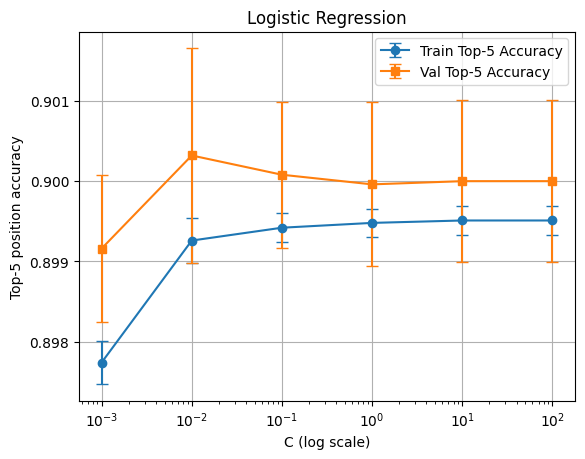

Best C (by mean val top-5 across splits): 0.01


In [48]:
plt.figure()

plt.xscale("log")
plt.errorbar(
    C_values,
    train_mean,
    yerr=train_se,
    marker="o",
    linestyle="-",
    capsize=4,
    label="Train Top-5 Accuracy"
)
plt.errorbar(
    C_values,
    val_mean,
    yerr=val_se,
    marker="s",
    linestyle="-",
    capsize=4,
    label="Val Top-5 Accuracy"
)

plt.xlabel("C (log scale)")
plt.ylabel("Top-5 position accuracy")
plt.title("Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

best_idx = int(np.argmax(val_mean))
best_C   = C_values[best_idx]
print(f"Best C (by mean val top-5 across splits): {best_C:.4g}")


## Ridge Classifier

In [66]:
ridge = RidgeClassifier(alpha=1.0, class_weight="balanced")
ridge.fit(X_train, y_train)

y_val_pred_ridge = ridge.predict(X_val)
print("Validation accuracy (ridge):", accuracy_score(y_val, y_val_pred_ridge))

# Calculate accuracy for Ridge Regression
def position_topk_accuracy_ridge(model, X, y, pos_ids, k=5):
    scores = model.decision_function(X)
    df = pd.DataFrame({"pos_id": pos_ids, "score": scores, "y": y})

    correct = 0
    total = 0

    for pid, group in df.groupby("pos_id"):
        # indices of moves with highest prob
        group_sorted = group.sort_values("score", ascending=False)
        # take the top k moves
        topk = group_sorted.head(k)
        # check if that move has label = 1
        if (topk["y"] == 1).any():
            correct += 1
        total += 1

    if total == 0:
        return 0
    return correct / total

val_pos_top5_ridge = position_topk_accuracy_ridge(ridge, X_val, y_val, pos_val, k=5)
print("position top-5 accuracy:", val_pos_top5_ridge)

Validation accuracy (ridge): 0.9000843082559641
position top-5 accuracy: 0.9016


## Hyperparameter for Ridge Regression

In [ ]:
# X, y, pos_ids already defined
n_splits = 5
splitter = GroupShuffleSplit(n_splits=n_splits, test_size=0.2, random_state=42)
splits = list(splitter.split(X, y, groups=pos_ids))

In [67]:
alpha_values = np.logspace(-3, 2, 6)

ridge_train_mean = []
ridge_val_mean   = []
ridge_train_se   = []
ridge_val_se     = []

for alpha in alpha_values:
    print(f"\n=== alpha = {alpha:.4g} ===")
    split_train_scores = []
    split_val_scores   = []

    for split_idx, (train_idx, val_idx) in enumerate(splits):
        print(f"  Split {split_idx + 1}/{n_splits}")

        X_train, y_train, pos_train = X[train_idx], y[train_idx], pos_ids[train_idx]
        X_val,   y_val,   pos_val   = X[val_idx],  y[val_idx],  pos_ids[val_idx]

        ridge = RidgeClassifier(alpha=alpha, class_weight="balanced")
        ridge.fit(X_train, y_train)

        train_top5 = position_topk_accuracy_ridge(ridge, X_train, y_train, pos_train, k=5)
        val_top5   = position_topk_accuracy_ridge(ridge, X_val,   y_val,   pos_val,   k=5)

        split_train_scores.append(train_top5)
        split_val_scores.append(val_top5)

        print(f"    Train top-5: {train_top5:.4f}, Val top-5: {val_top5:.4f}")

    split_train_scores = np.array(split_train_scores)
    split_val_scores   = np.array(split_val_scores)

    m_train = split_train_scores.mean()
    m_val   = split_val_scores.mean()

    se_train = split_train_scores.std(ddof=1) / np.sqrt(n_splits)
    se_val   = split_val_scores.std(ddof=1)   / np.sqrt(n_splits)

    ridge_train_mean.append(m_train)
    ridge_val_mean.append(m_val)
    ridge_train_se.append(se_train)
    ridge_val_se.append(se_val)

    print(f"  => Mean train top-5: {m_train:.4f} ± {se_train:.4f}")
    print(f"  => Mean val   top-5: {m_val:.4f} ± {se_val:.4f}")

ridge_train_mean = np.array(ridge_train_mean)
ridge_val_mean   = np.array(ridge_val_mean)
ridge_train_se   = np.array(ridge_train_se)
ridge_val_se     = np.array(ridge_val_se)


=== alpha = 0.001 ===
  Split 1/5
    Train top-5: 0.8976, Val top-5: 0.8964
  Split 2/5
    Train top-5: 0.8993, Val top-5: 0.8968
  Split 3/5
    Train top-5: 0.8983, Val top-5: 0.8960
  Split 4/5
    Train top-5: 0.8981, Val top-5: 0.9014
  Split 5/5
    Train top-5: 0.8973, Val top-5: 0.9016
  => Mean train top-5: 0.8981 ± 0.0003
  => Mean val   top-5: 0.8984 ± 0.0013

=== alpha = 0.01 ===
  Split 1/5
    Train top-5: 0.8976, Val top-5: 0.8964
  Split 2/5
    Train top-5: 0.8993, Val top-5: 0.8968
  Split 3/5
    Train top-5: 0.8983, Val top-5: 0.8960
  Split 4/5
    Train top-5: 0.8981, Val top-5: 0.9014
  Split 5/5
    Train top-5: 0.8973, Val top-5: 0.9016
  => Mean train top-5: 0.8981 ± 0.0003
  => Mean val   top-5: 0.8984 ± 0.0013

=== alpha = 0.1 ===
  Split 1/5
    Train top-5: 0.8976, Val top-5: 0.8964
  Split 2/5
    Train top-5: 0.8993, Val top-5: 0.8968
  Split 3/5
    Train top-5: 0.8983, Val top-5: 0.8960
  Split 4/5
    Train top-5: 0.8981, Val top-5: 0.9014
  Split 

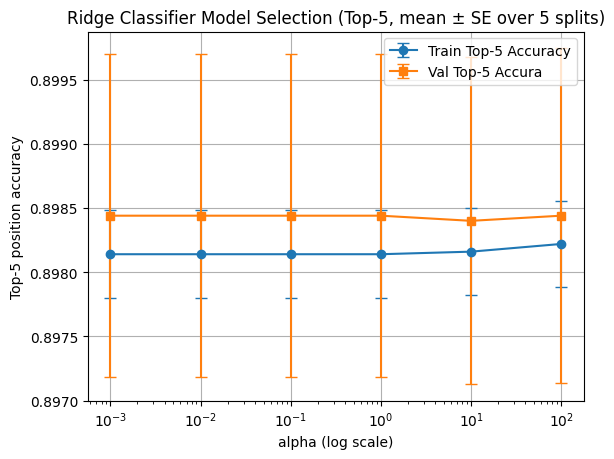

Best alpha by mean val Top-5 across splits: 0.001


In [72]:
plt.figure()

plt.xscale("log")
plt.errorbar(
    alpha_values,
    ridge_train_mean,
    yerr=ridge_train_se,
    marker="o",
    linestyle="-",
    capsize=4,
    label="Train Top-5 Accuracy"
)
plt.errorbar(
    alpha_values,
    ridge_val_mean,
    yerr=ridge_val_se,
    marker="s",
    linestyle="-",
    capsize=4,
    label="Val Top-5 Accura"
)

plt.xlabel("alpha (log scale)")
plt.ylabel("Top-5 position accuracy")
plt.title("Ridge Classifier Model Selection (Top-5, mean ± SE over 5 splits)")
plt.legend()
plt.grid(True)
plt.show()

best_idx_ridge = int(np.argmax(ridge_val_mean))
best_alpha     = alpha_values[best_idx_ridge]
print(f"Best alpha by mean val Top-5 across splits: {best_alpha:.4g}")

## Linear SVM

In [74]:
lin_svm = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=10000,
    random_state=0
)
lin_svm.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,0


### Hyperparameter Linear SVM

In [75]:
n_splits = 5
splitter = GroupShuffleSplit(n_splits=n_splits, test_size=0.2, random_state=42)

# Precompute splits once, reuse for all C and all models
splits = list(splitter.split(X, y, groups=pos_ids))
print(f"Number of splits: {len(splits)}")

Number of splits: 5


In [76]:
def position_topk_accuracy_svm_linear(model, X, y, pos_ids, k=5):
    scores = model.decision_function(X)
    df = pd.DataFrame({"pos_id": pos_ids, "score": scores, "y": y})

    correct = 0
    total = 0

    for pid, group in df.groupby("pos_id"):
        group_sorted = group.sort_values("score", ascending=False)
        topk = group_sorted.head(k)
        if (topk["y"] == 1).any():
            correct += 1
        total += 1

        if total == 0:
            return 0
    return correct / total

In [81]:
C_values = np.logspace(-3, 3, 7)

svm_train_mean = []
svm_val_mean   = []
svm_train_se   = []
svm_val_se     = []

for C in C_values:
    print(f"\n=== C = {C:.4g} ===")
    split_train_scores = []
    split_val_scores   = []

    for split_idx, (train_idx, val_idx) in enumerate(splits):
        print(f"  Split {split_idx + 1}/{n_splits}")

        X_train, y_train, pos_train = X[train_idx], y[train_idx], pos_ids[train_idx]
        X_val,   y_val,   pos_val   = X[val_idx],  y[val_idx],  pos_ids[val_idx]

        lin_svm = LinearSVC(
            C=C,
            class_weight="balanced",
            max_iter=10000,
            random_state=0
        )
        lin_svm.fit(X_train, y_train)

        train_top5 = position_topk_accuracy_svm_linear(lin_svm, X_train, y_train, pos_train, k=5)
        val_top5   = position_topk_accuracy_svm_linear(lin_svm, X_val,   y_val,   pos_val,   k=5)

        split_train_scores.append(train_top5)
        split_val_scores.append(val_top5)

        print(f"    Train top-5: {train_top5:.4f}, Val top-5: {val_top5:.4f}")

    split_train_scores = np.array(split_train_scores)
    split_val_scores   = np.array(split_val_scores)

    m_train = split_train_scores.mean()
    m_val   = split_val_scores.mean()

    se_train = split_train_scores.std(ddof=1) / np.sqrt(n_splits)
    se_val   = split_val_scores.std(ddof=1)   / np.sqrt(n_splits)

    svm_train_mean.append(m_train)
    svm_val_mean.append(m_val)
    svm_train_se.append(se_train)
    svm_val_se.append(se_val)

    print(f"  => Mean train top-5: {m_train:.4f} ± {se_train:.4f}")
    print(f"  => Mean val   top-5: {m_val:.4f} ± {se_val:.4f}")

svm_train_mean = np.array(svm_train_mean)
svm_val_mean   = np.array(svm_val_mean)
svm_train_se   = np.array(svm_train_se)
svm_val_se     = np.array(svm_val_se)


=== C = 0.001 ===
  Split 1/5
    Train top-5: 0.9001, Val top-5: 0.8978
  Split 2/5
    Train top-5: 0.9003, Val top-5: 0.9024
  Split 3/5
    Train top-5: 0.9002, Val top-5: 0.8992
  Split 4/5
    Train top-5: 0.8997, Val top-5: 0.9046
  Split 5/5
    Train top-5: 0.8997, Val top-5: 0.9022
  => Mean train top-5: 0.9000 ± 0.0001
  => Mean val   top-5: 0.9012 ± 0.0012

=== C = 0.01 ===
  Split 1/5
    Train top-5: 0.9000, Val top-5: 0.8992
  Split 2/5
    Train top-5: 0.9001, Val top-5: 0.9026
  Split 3/5
    Train top-5: 0.9001, Val top-5: 0.8992
  Split 4/5
    Train top-5: 0.8999, Val top-5: 0.9038
  Split 5/5
    Train top-5: 0.8999, Val top-5: 0.9030
  => Mean train top-5: 0.9000 ± 0.0000
  => Mean val   top-5: 0.9016 ± 0.0010

=== C = 0.1 ===
  Split 1/5
    Train top-5: 0.9000, Val top-5: 0.8996
  Split 2/5
    Train top-5: 0.9001, Val top-5: 0.9024
  Split 3/5
    Train top-5: 0.9001, Val top-5: 0.8990
  Split 4/5
    Train top-5: 0.8998, Val top-5: 0.9038
  Split 5/5
    Trai

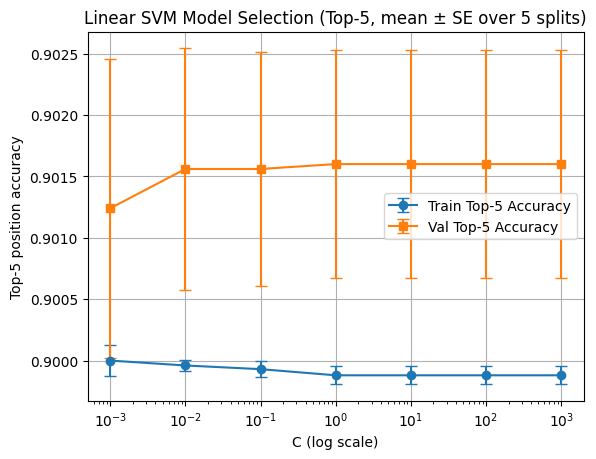

Best C for Linear SVM (mean val top-5 across splits): 1


In [82]:
plt.figure()

plt.xscale("log")
plt.errorbar(
    C_values,
    svm_train_mean,
    yerr=svm_train_se,
    marker="o",
    linestyle="-",
    capsize=4,
    label="Train Top-5 Accuracy"
)
plt.errorbar(
    C_values,
    svm_val_mean,
    yerr=svm_val_se,
    marker="s",
    linestyle="-",
    capsize=4,
    label="Val Top-5 Accuracy"
)

plt.xlabel("C (log scale)")
plt.ylabel("Top-5 position accuracy")
plt.title("Linear SVM Model Selection (Top-5, mean ± SE over 5 splits)")
plt.legend()
plt.grid(True)
plt.show()

best_idx_svm = int(np.argmax(svm_val_mean))
best_C_svm   = C_values[best_idx_svm]
print(f"Best C for Linear SVM (mean val top-5 across splits): {best_C_svm:.4g}")

## RBF SVM

In [11]:
svm_rbf = make_pipeline(
                MinMaxScaler(),
                SVC(
                    kernel="rbf",
                    C=1,
                    gamma=0.1,
                    class_weight="balanced",
                    max_iter=5000,
                    tol=1e-2,
                    probability=False,
                    random_state=0,
                )
            )

svm_rbf.fit(X_train, y_train);

C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [7]:
# X, y, pos_ids defined
n_splits = 3
splitter = GroupShuffleSplit(n_splits=n_splits, test_size=0.2, random_state=42)
splits = list(splitter.split(X, y, groups=pos_ids))
print(f"Number of splits: {len(splits)}")

Number of splits: 3


In [8]:
def position_topk_accuracy_svc(model, X, y, pos_ids, k=5):
    scores = model.decision_function(X)          # shape (N,) or (N,); for binary, 1D
    scores  = np.asarray(scores).ravel()
    y       = np.asarray(y)
    pos_ids = np.asarray(pos_ids)

    assert scores.shape[0] == y.shape[0] == pos_ids.shape[0]

    # Build groups: indices per position
    idx_by_pos = {}
    for idx, pid in enumerate(pos_ids):
        idx_by_pos.setdefault(pid, []).append(idx)
    groups = [np.array(idxs, dtype=int) for idxs in idx_by_pos.values()]

    correct = 0
    total = 0

    for idxs in groups:
        if idxs.size == 0:
            continue

        group_scores = scores[idxs]
        group_y      = y[idxs]

        k_eff = min(k, group_scores.size)
        topk_rel = np.argpartition(-group_scores, k_eff - 1)[:k_eff]

        if (group_y[topk_rel] == 1).any():
            correct += 1
        total += 1

    return 0.0 if total == 0 else correct / total


### Hyperparameter of RBF SVM

In [9]:
C_values_svm_rbf     = np.logspace(-1, 3, 5)   # [0.1, ..., 1000]
gamma_values_svm_rbf = np.logspace(-4, 1, 6)   # [1e-4, ..., 10]

# mean and SE over splits, shape = (len(C), len(gamma))
rbf_train_mean = np.zeros((len(C_values_svm_rbf), len(gamma_values_svm_rbf)))
rbf_val_mean   = np.zeros_like(rbf_train_mean)
rbf_train_se   = np.zeros_like(rbf_train_mean)
rbf_val_se     = np.zeros_like(rbf_train_mean)

for i, C in enumerate(C_values_svm_rbf):
    for j, gamma in enumerate(gamma_values_svm_rbf):
        print(f"\n=== RBF SVM: C = {C:.4g}, gamma = {gamma:.4g} ===")

        split_train_scores = []
        split_val_scores   = []

        for split_idx, (train_idx, val_idx) in enumerate(splits):
            print(f"  Split {split_idx + 1}/{n_splits}")

            X_train, y_train, pos_train = X[train_idx], y[train_idx], pos_ids[train_idx]
            X_val,   y_val,   pos_val   = X[val_idx],  y[val_idx],  pos_ids[val_idx]

            svm_rbf = make_pipeline(
                StandardScaler(),
                SVC(
                    kernel="rbf",
                    C=C,
                    gamma=gamma,
                    class_weight="balanced",
                    max_iter=5000,
                    tol=1e-2,
                    probability=False,
                    random_state=0,
                )
            )

            svm_rbf.fit(X_train, y_train)

            train_top5 = position_topk_accuracy_svc(svm_rbf, X_train, y_train, pos_train, k=5)
            val_top5   = position_topk_accuracy_svc(svm_rbf, X_val,   y_val,   pos_val,   k=5)

            split_train_scores.append(train_top5)
            split_val_scores.append(val_top5)

            print(f"    Train top-5: {train_top5:.4f}, Val top-5: {val_top5:.4f}")

        split_train_scores = np.array(split_train_scores)
        split_val_scores   = np.array(split_val_scores)

        m_train = split_train_scores.mean()
        m_val   = split_val_scores.mean()

        se_train = split_train_scores.std(ddof=1) / np.sqrt(n_splits)
        se_val   = split_val_scores.std(ddof=1)   / np.sqrt(n_splits)

        rbf_train_mean[i, j] = m_train
        rbf_val_mean[i, j]   = m_val
        rbf_train_se[i, j]   = se_train
        rbf_val_se[i, j]     = se_val

        print(f"  => Mean train top-5: {m_train:.4f} ± {se_train:.4f}")
        print(f"  => Mean val   top-5: {m_val:.4f} ± {se_val:.4f}")


=== RBF SVM: C = 0.1, gamma = 0.0001 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6197, Val top-5: 0.6142
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6165, Val top-5: 0.6152
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6131, Val top-5: 0.6250
  => Mean train top-5: 0.6164 ± 0.0019
  => Mean val   top-5: 0.6181 ± 0.0034

=== RBF SVM: C = 0.1, gamma = 0.001 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6184, Val top-5: 0.6116
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6165, Val top-5: 0.6154
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6132, Val top-5: 0.6250
  => Mean train top-5: 0.6160 ± 0.0015
  => Mean val   top-5: 0.6173 ± 0.0040

=== RBF SVM: C = 0.1, gamma = 0.01 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6220, Val top-5: 0.6158
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6206, Val top-5: 0.6190
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6152, Val top-5: 0.6274
  => Mean train top-5: 0.6193 ± 0.0021
  => Mean val   top-5: 0.6207 ± 0.0035

=== RBF SVM: C = 0.1, gamma = 0.1 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8535, Val top-5: 0.8604
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8544, Val top-5: 0.8478
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8547, Val top-5: 0.8578
  => Mean train top-5: 0.8542 ± 0.0004
  => Mean val   top-5: 0.8553 ± 0.0038

=== RBF SVM: C = 0.1, gamma = 1 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8624, Val top-5: 0.8598
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8662, Val top-5: 0.8662
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8666, Val top-5: 0.8682
  => Mean train top-5: 0.8651 ± 0.0013
  => Mean val   top-5: 0.8647 ± 0.0025

=== RBF SVM: C = 0.1, gamma = 10 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.3097, Val top-5: 0.3122
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.3214, Val top-5: 0.3190
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.3195, Val top-5: 0.3230
  => Mean train top-5: 0.3169 ± 0.0036
  => Mean val   top-5: 0.3181 ± 0.0032

=== RBF SVM: C = 1, gamma = 0.0001 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6197, Val top-5: 0.6142
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6165, Val top-5: 0.6152
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6131, Val top-5: 0.6250
  => Mean train top-5: 0.6164 ± 0.0019
  => Mean val   top-5: 0.6181 ± 0.0034

=== RBF SVM: C = 1, gamma = 0.001 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6184, Val top-5: 0.6116
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6165, Val top-5: 0.6154
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6132, Val top-5: 0.6250
  => Mean train top-5: 0.6160 ± 0.0015
  => Mean val   top-5: 0.6173 ± 0.0040

=== RBF SVM: C = 1, gamma = 0.01 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6220, Val top-5: 0.6158
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6206, Val top-5: 0.6190
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6152, Val top-5: 0.6274
  => Mean train top-5: 0.6193 ± 0.0021
  => Mean val   top-5: 0.6207 ± 0.0035

=== RBF SVM: C = 1, gamma = 0.1 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.7660, Val top-5: 0.7684
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8544, Val top-5: 0.8478
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8547, Val top-5: 0.8578
  => Mean train top-5: 0.8250 ± 0.0295
  => Mean val   top-5: 0.8247 ± 0.0283

=== RBF SVM: C = 1, gamma = 1 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8359, Val top-5: 0.8352
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8794, Val top-5: 0.8736
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8676, Val top-5: 0.8650
  => Mean train top-5: 0.8610 ± 0.0130
  => Mean val   top-5: 0.8579 ± 0.0116

=== RBF SVM: C = 1, gamma = 10 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.3126, Val top-5: 0.3192
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.3104, Val top-5: 0.3120
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.3193, Val top-5: 0.3294
  => Mean train top-5: 0.3141 ± 0.0027
  => Mean val   top-5: 0.3202 ± 0.0050

=== RBF SVM: C = 10, gamma = 0.0001 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6184, Val top-5: 0.6116
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6165, Val top-5: 0.6152
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6131, Val top-5: 0.6250
  => Mean train top-5: 0.6160 ± 0.0016
  => Mean val   top-5: 0.6173 ± 0.0040

=== RBF SVM: C = 10, gamma = 0.001 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6184, Val top-5: 0.6116
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6165, Val top-5: 0.6154
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6132, Val top-5: 0.6250
  => Mean train top-5: 0.6160 ± 0.0015
  => Mean val   top-5: 0.6173 ± 0.0040

=== RBF SVM: C = 10, gamma = 0.01 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8438, Val top-5: 0.8404
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8423, Val top-5: 0.8344
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8394, Val top-5: 0.8430
  => Mean train top-5: 0.8418 ± 0.0013
  => Mean val   top-5: 0.8393 ± 0.0025

=== RBF SVM: C = 10, gamma = 0.1 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8600, Val top-5: 0.8582
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8416, Val top-5: 0.8296
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8737, Val top-5: 0.8800
  => Mean train top-5: 0.8584 ± 0.0093
  => Mean val   top-5: 0.8559 ± 0.0146

=== RBF SVM: C = 10, gamma = 1 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8533, Val top-5: 0.8540
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8631, Val top-5: 0.8610
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8645, Val top-5: 0.8594
  => Mean train top-5: 0.8603 ± 0.0035
  => Mean val   top-5: 0.8581 ± 0.0021

=== RBF SVM: C = 10, gamma = 10 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.2950, Val top-5: 0.2952
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.3220, Val top-5: 0.3274
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.3302, Val top-5: 0.3296
  => Mean train top-5: 0.3157 ± 0.0106
  => Mean val   top-5: 0.3174 ± 0.0111

=== RBF SVM: C = 100, gamma = 0.0001 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6184, Val top-5: 0.6116
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6165, Val top-5: 0.6152
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.6131, Val top-5: 0.6250
  => Mean train top-5: 0.6160 ± 0.0016
  => Mean val   top-5: 0.6173 ± 0.0040

=== RBF SVM: C = 100, gamma = 0.001 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8286, Val top-5: 0.8264
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8292, Val top-5: 0.8176
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8251, Val top-5: 0.8316
  => Mean train top-5: 0.8276 ± 0.0013
  => Mean val   top-5: 0.8252 ± 0.0041

=== RBF SVM: C = 100, gamma = 0.01 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8502, Val top-5: 0.8488
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8404, Val top-5: 0.8340
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8462, Val top-5: 0.8492
  => Mean train top-5: 0.8456 ± 0.0029
  => Mean val   top-5: 0.8440 ± 0.0050

=== RBF SVM: C = 100, gamma = 0.1 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8600, Val top-5: 0.8582
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8416, Val top-5: 0.8296
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8737, Val top-5: 0.8800
  => Mean train top-5: 0.8584 ± 0.0093
  => Mean val   top-5: 0.8559 ± 0.0146

=== RBF SVM: C = 100, gamma = 1 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8533, Val top-5: 0.8540
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8631, Val top-5: 0.8610
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8645, Val top-5: 0.8594
  => Mean train top-5: 0.8603 ± 0.0035
  => Mean val   top-5: 0.8581 ± 0.0021

=== RBF SVM: C = 100, gamma = 10 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.3105, Val top-5: 0.3176
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.3104, Val top-5: 0.3120
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.3302, Val top-5: 0.3296
  => Mean train top-5: 0.3170 ± 0.0066
  => Mean val   top-5: 0.3197 ± 0.0052

=== RBF SVM: C = 1000, gamma = 0.0001 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8286, Val top-5: 0.8264
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8569, Val top-5: 0.8484
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8251, Val top-5: 0.8316
  => Mean train top-5: 0.8369 ± 0.0100
  => Mean val   top-5: 0.8355 ± 0.0066

=== RBF SVM: C = 1000, gamma = 0.001 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8502, Val top-5: 0.8486
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.4451, Val top-5: 0.4464
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8467, Val top-5: 0.8484
  => Mean train top-5: 0.7140 ± 0.1345
  => Mean val   top-5: 0.7145 ± 0.1340

=== RBF SVM: C = 1000, gamma = 0.01 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8502, Val top-5: 0.8488
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8404, Val top-5: 0.8340
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8462, Val top-5: 0.8492
  => Mean train top-5: 0.8456 ± 0.0029
  => Mean val   top-5: 0.8440 ± 0.0050

=== RBF SVM: C = 1000, gamma = 0.1 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8600, Val top-5: 0.8582
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8416, Val top-5: 0.8296
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8737, Val top-5: 0.8800
  => Mean train top-5: 0.8584 ± 0.0093
  => Mean val   top-5: 0.8559 ± 0.0146

=== RBF SVM: C = 1000, gamma = 1 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8609, Val top-5: 0.8662
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8615, Val top-5: 0.8644
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.8673, Val top-5: 0.8688
  => Mean train top-5: 0.8632 ± 0.0020
  => Mean val   top-5: 0.8665 ± 0.0013

=== RBF SVM: C = 1000, gamma = 10 ===
  Split 1/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.3126, Val top-5: 0.3192
  Split 2/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.3104, Val top-5: 0.3120
  Split 3/3


C:\Users\James_X\anaconda3\envs\torch312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Train top-5: 0.3302, Val top-5: 0.3296
  => Mean train top-5: 0.3177 ± 0.0063
  => Mean val   top-5: 0.3203 ± 0.0051


In [10]:
best_idx = np.unravel_index(np.argmax(rbf_val_mean), rbf_val_mean.shape)
best_C     = C_values_svm_rbf[best_idx[0]]
best_gamma = gamma_values_svm_rbf[best_idx[1]]
best_val   = rbf_val_mean[best_idx]
best_se    = rbf_val_se[best_idx]

print("\nBest RBF SVM hyperparameters (mean over 5 splits):")
print(f"  C      = {best_C}")
print(f"  gamma  = {best_gamma}")
print(f"  val top-5 (mean ± SE) = {best_val:.4f} ± {best_se:.4f}")


Best RBF SVM hyperparameters (mean over 5 splits):
  C      = 1000.0
  gamma  = 1.0
  val top-5 (mean ± SE) = 0.8665 ± 0.0013


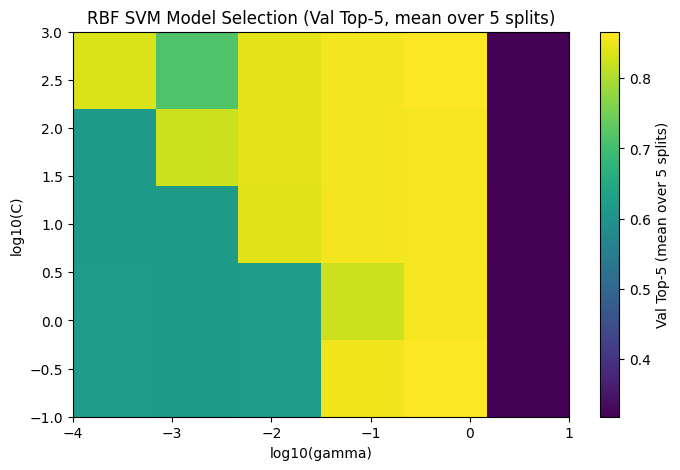

In [11]:
plt.figure(figsize=(8, 5))
im = plt.imshow(
    rbf_val_mean,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    extent=[
        np.log10(gamma_values_svm_rbf[0]),
        np.log10(gamma_values_svm_rbf[-1]),
        np.log10(C_values_svm_rbf[0]),
        np.log10(C_values_svm_rbf[-1]),
    ],
)
plt.colorbar(im, label="Val Top-5 (mean over 5 splits)")
plt.xlabel("log10(gamma)")
plt.ylabel("log10(C)")
plt.title("RBF SVM Model Selection (Val Top-5, mean over 5 splits)")
plt.show()

## MLP

In [8]:
import itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
device = torch.device("cpu")
print("Using device:", device)

Using device: cpu


In [6]:
n_splits = 5
splitter = GroupShuffleSplit(n_splits=n_splits, test_size=0.2, random_state=42)
splits = list(splitter.split(X, y, groups=pos_ids))

In [9]:
class MoveMLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes, dropout=0.0):
        super().__init__()
        layers = []
        prev = input_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            if dropout > 0.0:
                layers.append(nn.Dropout(dropout))
            prev = h

        # Final scalar output
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # x: (N, input_dim)
        out = self.net(x)          # (N, 1)
        return out.squeeze(-1)     # (N,)

In [10]:
def train_mlp_one_split(
    train_idx,
    val_idx,
    X,
    y,
    pos_ids,
    input_dim,
    hidden_sizes,
    lr=1e-3,
    dropout=0.0,
    weight_decay=0.0,
    num_epochs=10,
):
    # Slice data
    X_train, y_train, pos_train = X[train_idx], y[train_idx], pos_ids[train_idx]
    X_val,   y_val,   pos_val   = X[val_idx],   y[val_idx],   pos_ids[val_idx]

    # To torch
    X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32, device=device)
    pos_train_t = torch.tensor(pos_train, dtype=torch.long, device=device)

    # Model & optimizer
    model = MoveMLP(
        input_dim=input_dim,
        hidden_sizes=hidden_sizes,
        dropout=dropout,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    for epoch in range(1, num_epochs + 1):
        model.train()
        optimizer.zero_grad()

        logits = model(X_train_t)  # (N_train,)
        loss = position_cross_entropy_loss(logits, y_train_t, pos_train_t)
        loss.backward()
        optimizer.step()

    # Validation top-5 accuracy
    val_top5 = position_topk_accuracy_mlp_model(
        model,
        X_val,
        y_val,
        pos_val,
        k=5,
    )
    return model, val_top5

In [11]:
def position_cross_entropy_loss(logits, y, pos_ids):
    device = logits.device

    logits  = logits.view(-1)
    y       = y.view(-1)
    pos_ids = pos_ids.view(-1)

    unique_pos = torch.unique(pos_ids)
    losses = []

    for pid in unique_pos:
        mask = (pos_ids == pid)
        if not mask.any():
            continue

        group_logits = logits[mask]         # (num_moves_pos,)
        group_y      = y[mask]              # (num_moves_pos,)

        # Softmax over moves for this position
        log_probs = torch.log_softmax(group_logits, dim=0)

        # Find the (single) target move index
        target_idx = (group_y == 1).nonzero(as_tuple=False).view(-1)

        # If data is dirty (0 or >1 targets), skip this position
        if target_idx.numel() != 1:
            # raise ValueError(f"Position {pid.item()} has {target_idx.numel()} targets.")
            continue

        loss_pos = -log_probs[target_idx[0]]
        losses.append(loss_pos)

    if len(losses) == 0:
        # no valid positions — return 0 to avoid NaN
        return torch.tensor(0.0, device=device)

    return torch.stack(losses).mean()

def position_topk_accuracy_mlp_model(model, X, y, pos_ids, k=5):
    model.eval()
    device = next(model.parameters()).device

    # Move features to torch, run the model once
    with torch.no_grad():
        X_t = torch.tensor(X, dtype=torch.float32, device=device)
        logits = model(X_t).cpu().numpy()  # (N,)

    y = np.asarray(y)
    pos_ids = np.asarray(pos_ids)

    # Build groups: position ID → list of indices
    idx_by_pos = {}
    for idx, pid in enumerate(pos_ids):
        idx_by_pos.setdefault(pid, []).append(idx)

    groups = [np.array(idxs, dtype=int) for idxs in idx_by_pos.values()]

    correct = 0
    total   = 0

    for idxs in groups:
        if idxs.size == 0:
            continue

        group_logits = logits[idxs]
        group_y      = y[idxs]

        # Skip positions with no positive label (or >1 positives)
        pos_targets = np.where(group_y == 1)[0]
        if pos_targets.size != 1:
            # Same as in the loss: can choose to skip or enforce.
            continue

        # Effective k cannot exceed number of moves
        k_eff = int(min(k, group_logits.size))

        # Indices (relative to group) of top-k moves
        topk_rel = np.argpartition(-group_logits, k_eff - 1)[:k_eff]

        # Check if any of the top-k moves is the true target
        if np.any(group_y[topk_rel] == 1):
            correct += 1
        total += 1

    return 0.0 if total == 0 else correct / total

### Stage One - Hidden Layers

In [13]:
input_dim = X.shape[1]

widths = [32, 64, 128, 256]

arch_grid = []
for depth in [1, 2]:
    for combo in itertools.product(widths, repeat=depth):
        arch_grid.append(list(combo))

print("Total Number of architectures:", len(arch_grid))
# e.g., 4 + 16 = 20 configs if depth<=2

# Fixed training settings for arch search
arch_lr         = 1e-3
arch_dropout    = 0.0      # no dropout in Stage 1
arch_weight_dec = 0.0      # no weight decay in Stage 1
arch_epochs     = 10

arch_results = []

for hidden_sizes in arch_grid:
    arch_name = "-".join(str(h) for h in hidden_sizes)
    print(f"\n=== Hidden Layers: {arch_name} ===")

    split_scores = []

    for split_idx, (train_idx, val_idx) in enumerate(splits):
        print(f"  Split {split_idx+1}/{len(splits)} ...", end="", flush=True)

        _, val_top5 = train_mlp_one_split(
            train_idx=train_idx,
            val_idx=val_idx,
            X=X,
            y=y,
            pos_ids=pos_ids,
            input_dim=input_dim,
            hidden_sizes=hidden_sizes,
            lr=arch_lr,
            dropout=arch_dropout,
            weight_decay=arch_weight_dec,
            num_epochs=arch_epochs,
        )

        print(f" val top-5 = {val_top5:.4f}")
        split_scores.append(val_top5)

    split_scores = np.array(split_scores)
    m_val = split_scores.mean()
    se_val = split_scores.std(ddof=1) / np.sqrt(len(splits))

    print(f"  => Mean val top-5 = {m_val:.4f} ± {se_val:.4f}")

    arch_results.append({
        "hidden_sizes": hidden_sizes,
        "arch_name": arch_name,
        "val_top5_mean": m_val,
        "val_top5_se": se_val,
    })

arch_results_df = pd.DataFrame(arch_results)
arch_results_df.sort_values("val_top5_mean", ascending=False, inplace=True)
arch_results_df.head()


Total Number of architectures: 20

=== Hidden Layers: 32 ===
  Split 1/5 ... val top-5 = 0.3518
  Split 2/5 ... val top-5 = 0.0940
  Split 3/5 ... val top-5 = 0.1700
  Split 4/5 ... val top-5 = 0.5568
  Split 5/5 ... val top-5 = 0.4570
  => Mean val top-5 = 0.3259 ± 0.0864

=== Hidden Layers: 64 ===
  Split 1/5 ... val top-5 = 0.3640
  Split 2/5 ... val top-5 = 0.5256
  Split 3/5 ... val top-5 = 0.4184
  Split 4/5 ... val top-5 = 0.4684
  Split 5/5 ... val top-5 = 0.5402
  => Mean val top-5 = 0.4633 ± 0.0329

=== Hidden Layers: 128 ===
  Split 1/5 ... val top-5 = 0.5880
  Split 2/5 ... val top-5 = 0.6008
  Split 3/5 ... val top-5 = 0.5874
  Split 4/5 ... val top-5 = 0.7400
  Split 5/5 ... val top-5 = 0.6148
  => Mean val top-5 = 0.6262 ± 0.0289

=== Hidden Layers: 256 ===
  Split 1/5 ... val top-5 = 0.8024
  Split 2/5 ... val top-5 = 0.7880
  Split 3/5 ... val top-5 = 0.8574
  Split 4/5 ... val top-5 = 0.8138
  Split 5/5 ... val top-5 = 0.7986
  => Mean val top-5 = 0.8120 ± 0.0121

===

,hidden_sizes,arch_name,val_top5_mean,val_top5_se
18,"[256, 128]",256-128,0.87564,0.001673
17,"[256, 64]",256-64,0.87564,0.003565
14,"[128, 128]",128-128,0.87276,0.003384
19,"[256, 256]",256-256,0.87260,0.003418
16,"[256, 32]",256-32,0.87256,0.004108


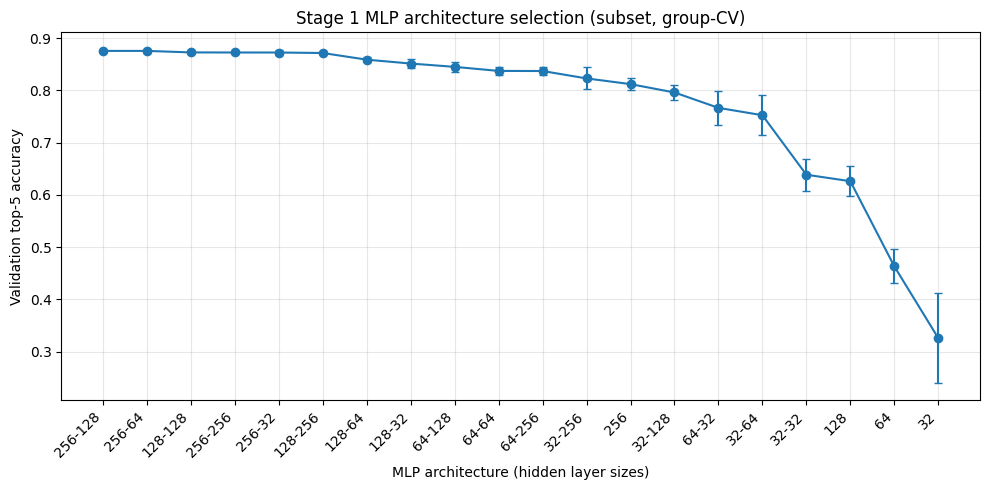

In [16]:
arch_results_df = pd.DataFrame(arch_results)
arch_results_df.sort_values("val_top5_mean", ascending=False, inplace=True)
arch_results_df.head()

# Sort architectures by validation performance (descending)
df_ranked = arch_results_df.sort_values("val_top5_mean", ascending=False).reset_index(drop=True)

# Optionally: only show top K architectures to keep it readable
K = min(50, len(df_ranked))
df_plot = df_ranked.iloc[:K].copy()

x = np.arange(len(df_plot))
y = df_plot["val_top5_mean"].values
yerr = df_plot["val_top5_se"].values
labels = df_plot["arch_name"].tolist()

plt.figure(figsize=(10, 5))
plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3)
plt.xticks(x, labels, rotation=45, ha="right")
plt.xlabel("MLP architecture (hidden layer sizes)")
plt.ylabel("Validation top-5 accuracy")
plt.title("Stage 1 MLP architecture selection (subset, group-CV)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
best_arch_row = arch_results_df.iloc[0]
best_hidden_sizes = best_arch_row["hidden_sizes"]

print("Best architecture:", best_arch_row["arch_name"])
print("Mean val top-5:", best_arch_row["val_top5_mean"])


Best architecture: 256-128
Mean val top-5: 0.87564


### Stage Two

In [18]:
X = np.vstack(X_list)
y = np.array(y_list)
pos_ids = np.array(pos_ids, dtype=np.int64)

In [20]:
input_dim = X.shape[1]

dropout_grid      = [0.0, 0.1, 0.2]
weight_decay_grid = [0.0, 1e-4]
reg_lr_grid       = [1e-3, 1e-2, 1e-1, 1.0]
reg_epochs        = 10

n_splits = 3

reg_results = []

for dropout in dropout_grid:
    for wd in weight_decay_grid:
        for lr in reg_lr_grid:
            print(f"\n=== Reg search: dropout={dropout}, weight_decay={wd}, lr={lr} ===")

            split_scores = []

            # NEW: create GroupShuffleSplit *here* so it uses the current X, y, pos_ids
            gss = GroupShuffleSplit(
                n_splits=n_splits,
                test_size=0.2,
                random_state=42,  # fixed for reproducibility
            )

            for split_idx, (train_idx, val_idx) in enumerate(
                gss.split(X, y, groups=pos_ids)
            ):
                print(f"  Split {split_idx+1}/{n_splits} ...", end="", flush=True)

                # Optional: sanity check to see indices are valid
                # assert train_idx.max() < len(X)
                # assert val_idx.max() < len(X)

                _, val_top5 = train_mlp_one_split(
                    train_idx=train_idx,
                    val_idx=val_idx,
                    X=X,
                    y=y,
                    pos_ids=pos_ids,
                    input_dim=input_dim,
                    hidden_sizes=best_hidden_sizes,
                    lr=lr,
                    dropout=dropout,
                    weight_decay=wd,
                    num_epochs=reg_epochs,
                )

                print(f" val top-5 = {val_top5:.4f}")
                split_scores.append(val_top5)

            split_scores = np.array(split_scores)
            m_val = split_scores.mean()
            se_val = split_scores.std(ddof=1) / np.sqrt(n_splits)

            print(f"  => Mean val top-5 = {m_val:.4f} ± {se_val:.4f}")

            reg_results.append({
                "hidden_sizes": best_hidden_sizes,
                "dropout": dropout,
                "weight_decay": wd,
                "lr": lr,
                "val_top5_mean": m_val,
                "val_top5_se": se_val,
            })

reg_results_df = pd.DataFrame(reg_results)
reg_results_df.sort_values("val_top5_mean", ascending=False, inplace=True)
reg_results_df.head()


=== Reg search: dropout=0.0, weight_decay=0.0, lr=0.001 ===
  Split 1/3 ... val top-5 = 0.8988
  Split 2/3 ... val top-5 = 0.8756
  Split 3/3 ... val top-5 = 0.8668
  => Mean val top-5 = 0.8804 ± 0.0095

=== Reg search: dropout=0.0, weight_decay=0.0, lr=0.01 ===
  Split 1/3 ... val top-5 = 0.9092
  Split 2/3 ... val top-5 = 0.9134
  Split 3/3 ... val top-5 = 0.9130
  => Mean val top-5 = 0.9119 ± 0.0013

=== Reg search: dropout=0.0, weight_decay=0.0, lr=0.1 ===
  Split 1/3 ... val top-5 = 0.9030
  Split 2/3 ... val top-5 = 0.8884
  Split 3/3 ... val top-5 = 0.8716
  => Mean val top-5 = 0.8877 ± 0.0091

=== Reg search: dropout=0.0, weight_decay=0.0, lr=1.0 ===
  Split 1/3 ... val top-5 = 0.8046
  Split 2/3 ... val top-5 = 0.8710
  Split 3/3 ... val top-5 = 0.6966
  => Mean val top-5 = 0.7907 ± 0.0508

=== Reg search: dropout=0.0, weight_decay=0.0001, lr=0.001 ===
  Split 1/3 ... val top-5 = 0.8758
  Split 2/3 ... val top-5 = 0.8844
  Split 3/3 ... val top-5 = 0.8714
  => Mean val top-5 

,hidden_sizes,dropout,weight_decay,lr,val_top5_mean,val_top5_se
17,"[256, 128]",0.2,0.0000,0.01,0.913133,0.001122
1,"[256, 128]",0.0,0.0000,0.01,0.911867,0.001338
9,"[256, 128]",0.1,0.0000,0.01,0.910333,0.002562
21,"[256, 128]",0.2,0.0001,0.01,0.909133,0.003806
5,"[256, 128]",0.0,0.0001,0.01,0.909133,0.002954


## CNN

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import chess
import numpy as np
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [3]:
import itertools

conv_widths = [32, 64, 128, 256]

conv_grid = []

# Single-layer convs: (32,), (64,), ...
for w in conv_widths:
    conv_grid.append((w,))

# Two-layer convs: (32,32), (32,64), ..., (256,256)
for combo in itertools.product(conv_widths, repeat=2):
    conv_grid.append(combo)

print("Total CNN conv architectures:", len(conv_grid))
print(conv_grid[:10])  # quick peek

Total CNN conv architectures: 20
[(32,), (64,), (128,), (256,), (32, 32), (32, 64), (32, 128), (32, 256), (64, 32), (64, 64)]


In [66]:
import chess
import pandas as pd
import numpy as np

FEN_COL = "fen"
BEST_MOVE_COL = "best"

rows = []
for pos_id, (_, row) in enumerate(df_train.iterrows()):
    fen  = row[FEN_COL]
    best = row[BEST_MOVE_COL]  # UCI string of engine's mate-in-one move

    board = chess.Board(fen)

    for move in board.legal_moves:
        uci = move.uci()
        is_best = int(uci == best)  # 1 if this move is the best, else 0

        rows.append({
            "pos_id": pos_id,
            "fen": fen,
            "uci": uci,
            "label": is_best,   # <- this is the "label" we use later
        })

df_moves = pd.DataFrame(rows)
print(df_moves.head())


   pos_id                                                fen   uci  label
0       0  6qn/p5kp/PpQ2rp1/2n1NbP1/1PP2P1P/B1P1P3/8/7K w...  c6e8      0
1       0  6qn/p5kp/PpQ2rp1/2n1NbP1/1PP2P1P/B1P1P3/8/7K w...  c6c8      0
2       0  6qn/p5kp/PpQ2rp1/2n1NbP1/1PP2P1P/B1P1P3/8/7K w...  c6a8      0
3       0  6qn/p5kp/PpQ2rp1/2n1NbP1/1PP2P1P/B1P1P3/8/7K w...  c6d7      0
4       0  6qn/p5kp/PpQ2rp1/2n1NbP1/1PP2P1P/B1P1P3/8/7K w...  c6c7      0


In [67]:
def move_to_planes(move: chess.Move) -> np.ndarray:
    planes = np.zeros((2, 8, 8), dtype=np.float32)

    # From square
    from_sq = move.from_square
    from_rank = chess.square_rank(from_sq)
    from_file = chess.square_file(from_sq)
    from_row = 7 - from_rank        # same convention as board_to_planes
    from_col = from_file
    planes[0, from_row, from_col] = 1.0

    # To square
    to_sq = move.to_square
    to_rank = chess.square_rank(to_sq)
    to_file = chess.square_file(to_sq)
    to_row = 7 - to_rank
    to_col = to_file
    planes[1, to_row, to_col] = 1.0

    return planes


In [ ]:
# ---- Board encoder: FEN -> Cx8x8 planes ----

piece_planes = {
    (chess.PAWN,   chess.WHITE): 0,
    (chess.KNIGHT, chess.WHITE): 1,
    (chess.BISHOP, chess.WHITE): 2,
    (chess.ROOK,   chess.WHITE): 3,
    (chess.QUEEN,  chess.WHITE): 4,
    (chess.KING,   chess.WHITE): 5,
    (chess.PAWN,   chess.BLACK): 6,
    (chess.KNIGHT, chess.BLACK): 7,
    (chess.BISHOP, chess.BLACK): 8,
    (chess.ROOK,   chess.BLACK): 9,
    (chess.QUEEN,  chess.BLACK): 10,
    (chess.KING,   chess.BLACK): 11,
}
# 12 piece planes + 1 side-to-move + 4 castling = 17 channels
NUM_PLANES = 12 + 1 + 4

def board_to_planes(board: chess.Board) -> np.ndarray:
    planes = np.zeros((NUM_PLANES, 8, 8), dtype=np.float32)

    # Pieces
    for square, piece in board.piece_map().items():
        key = (piece.piece_type, piece.color)
        plane_idx = piece_planes[key]
        row = 7 - chess.square_rank(square)  # rank 0 at bottom
        col = chess.square_file(square)
        planes[plane_idx, row, col] = 1.0

    # Side to move
    planes[12, :, :] = 1.0 if board.turn == chess.WHITE else 0.0

    # Castling rights: [Wk, Wq, Bk, Bq]
    planes[13, :, :] = 1.0 if board.has_kingside_castling_rights(chess.WHITE) else 0.0
    planes[14, :, :] = 1.0 if board.has_queenside_castling_rights(chess.WHITE) else 0.0
    planes[15, :, :] = 1.0 if board.has_kingside_castling_rights(chess.BLACK) else 0.0
    planes[16, :, :] = 1.0 if board.has_queenside_castling_rights(chess.BLACK) else 0.0

    return planes

# ---- Build CNN dataset ----

X_cnn_list = []
y_list = []
pos_ids_list = []
boards_all = []
moves_all = []

for _, row in df_moves_sub.iterrows():  # or df_moves if not subsampling
    fen   = row["fen"]
    uci   = row["uci"]
    label = row["label"]
    pid   = row["pos_id"]

    board = chess.Board(fen)
    move  = chess.Move.from_uci(uci)

    board_planes = board_to_planes(board)     # (17, 8, 8)
    move_planes  = move_to_planes(move)       # (2, 8, 8)
    full_planes  = np.concatenate(
        [board_planes, move_planes], axis=0
    )                                         # (19, 8, 8)

    X_cnn_list.append(full_planes)
    y_list.append(label)
    pos_ids_list.append(pid)
    boards_all.append(board)
    moves_all.append(move)

X_cnn   = np.stack(X_cnn_list)         # (N, 19, 8, 8)
y       = np.array(y_list, dtype=int)
pos_ids = np.array(pos_ids_list, dtype=int)

print("X_cnn shape:", X_cnn.shape)  # check channels dimension = 19
print("len(y)     :", len(y))
print("len(pos_ids):", len(pos_ids))
assert len(X_cnn) == len(y) == len(pos_ids)


In [24]:
# df_moves has columns: ["pos_id", "fen", "uci", "label", ...]
print(df_moves["pos_id"].min(), df_moves["pos_id"].max())

# Keep only positions with pos_id < 5000  (i.e., first 5000 groups)
max_pos_id = 1000
df_moves_sub = df_moves[df_moves["pos_id"] < max_pos_id].copy()

print("Total moves before:", len(df_moves))
print("Total moves after subsetting:", len(df_moves_sub))
print("Unique positions after subsetting:", df_moves_sub["pos_id"].nunique())


0 24999
Total moves before: 957086
Total moves after subsetting: 38001
Unique positions after subsetting: 1000


In [25]:
def train_cnn_one_split(
    train_idx,
    val_idx,
    X,
    y,
    pos_ids,
    conv_channels=(32,),
    fc_dim=128,
    lr=1e-3,
    weight_decay=0.0,
    dropout=0.0,
    num_epochs=10,
    verbose=False,
):
    X_train, y_train, pos_train = X[train_idx], y[train_idx], pos_ids[train_idx]
    X_val,   y_val,   pos_val   = X[val_idx],   y[val_idx],   pos_ids[val_idx]

    # X is (N, C, 8, 8) already
    X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32, device=device)
    pos_train_t = torch.tensor(pos_train, dtype=torch.long, device=device)

    in_channels = X_train.shape[1]

    model = MoveCNN(
        in_channels=in_channels,
        conv_channels=conv_channels,
        fc_dim=fc_dim,
        dropout=dropout,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    for epoch in range(1, num_epochs + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train_t)
        loss = position_cross_entropy_loss(logits, y_train_t, pos_train_t)
        loss.backward()
        optimizer.step()

        if verbose and epoch in {1, num_epochs}:
            print(f"  Epoch {epoch:02d}/{num_epochs} | loss = {loss.item():.4f}")

    # validation logits
    model.eval()
    with torch.no_grad():
        X_val_t = torch.tensor(X_val, dtype=torch.float32, device=device)
        val_logits = model(X_val_t).cpu().numpy()

    val_top5 = position_topk_accuracy_from_logits(
        logits=val_logits,
        y=y_val,
        pos_ids=pos_val,
        k=5,
    )

    return model, val_top5


In [15]:
import torch
import torch.nn as nn

class MoveCNN(nn.Module):
    def __init__(self, in_channels, conv_channels=(32, 64), fc_dim=128, dropout=0.0):
        super().__init__()
        conv_layers = []
        c_prev = in_channels

        for c in conv_channels:
            conv_layers.append(nn.Conv2d(c_prev, c, kernel_size=3, padding=1))
            conv_layers.append(nn.ReLU())
            conv_layers.append(nn.MaxPool2d(kernel_size=2))  # 8x8 -> 4x4 -> 2x2
            c_prev = c

        self.conv = nn.Sequential(*conv_layers)

        # infer flatten size
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, 8, 8)
            out = self.conv(dummy)
            conv_out_dim = out.numel()

        fc_layers = [
            nn.Linear(conv_out_dim, fc_dim),
            nn.ReLU(),
        ]
        if dropout > 0.0:
            fc_layers.append(nn.Dropout(dropout))
        fc_layers.append(nn.Linear(fc_dim, 1))

        self.fc = nn.Sequential(*fc_layers)

    def forward(self, x):
        # x: (N, C, 8, 8)
        out = self.conv(x)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out.squeeze(-1)  # (N,)


[9] Bengal1, “GitHub - Bengal1/Simple-CNN-Guide: A beginner’s guide to building Convolutional Neural Networks (CNNs).,” GitHub, 2025. https://github.com/Bengal1/Simple-CNN-Guide (accessed Dec. 6, 2025).

In [16]:
def position_cross_entropy_loss(logits, y, pos_ids):
    device = logits.device

    logits  = logits.view(-1)
    y       = y.view(-1)
    pos_ids = pos_ids.view(-1)

    unique_pos = torch.unique(pos_ids)
    losses = []

    for pid in unique_pos:
        mask = (pos_ids == pid)
        if not mask.any():
            continue

        gl = logits[mask]
        gy = y[mask]

        log_probs = torch.log_softmax(gl, dim=0)
        target_idx = (gy == 1).nonzero(as_tuple=False).view(-1)

        if target_idx.numel() != 1:
            continue

        loss_pos = -log_probs[target_idx[0]]
        losses.append(loss_pos)

    if len(losses) == 0:
        return torch.tensor(0.0, device=device)

    return torch.stack(losses).mean()


In [17]:
def position_topk_accuracy_from_logits(logits, y, pos_ids, k=5):
    logits = np.asarray(logits)
    y = np.asarray(y)
    pos_ids = np.asarray(pos_ids)

    idx_by_pos = {}
    for idx, pid in enumerate(pos_ids):
        idx_by_pos.setdefault(pid, []).append(idx)

    correct, total = 0, 0

    for idxs in idx_by_pos.values():
        if len(idxs) == 0:
            continue
        idxs = np.array(idxs, dtype=int)
        g_logits = logits[idxs]
        g_y      = y[idxs]

        targets = np.where(g_y == 1)[0]
        if targets.size != 1:
            continue

        k_eff = min(k, len(g_logits))
        topk_rel = np.argpartition(-g_logits, k_eff - 1)[:k_eff]

        if np.any(g_y[topk_rel] == 1):
            correct += 1
        total += 1

    return 0.0 if total == 0 else correct / total


In [20]:
torch.cuda.empty_cache()

In [26]:

from sklearn.model_selection import GroupShuffleSplit
import numpy as np
import pandas as pd

print("len(X_cnn)=", len(X_cnn), "len(y)=", len(y), "len(pos_ids)=", len(pos_ids))
assert len(X_cnn) == len(y) == len(pos_ids)

# 5 group-aware splits
n_splits_arch = 5
splitter_arch = GroupShuffleSplit(
    n_splits=n_splits_arch,
    test_size=0.2,
    random_state=42,
)

splits_arch = list(splitter_arch.split(X_cnn, y, groups=pos_ids))

arch_results_cnn = []

cnn_lr      = 1e-3
cnn_wd      = 0.0
cnn_dropout = 0.1
cnn_epochs  = 10  # keep modest so the grid is tractable

for conv_channels in conv_grid:
    arch_name = "-".join(str(c) for c in conv_channels)
    print(f"\n=== CNN conv_channels: {arch_name} ===")

    split_scores = []

    for split_idx, (train_idx, val_idx) in enumerate(splits_arch):
        print(f"  Split {split_idx+1}/{n_splits_arch} ...", end="", flush=True)

        _, val_top5 = train_cnn_one_split(
            train_idx=train_idx,
            val_idx=val_idx,
            X=X_cnn,
            y=y,
            pos_ids=pos_ids,
            conv_channels=conv_channels,
            fc_dim=128,
            lr=cnn_lr,
            weight_decay=cnn_wd,
            dropout=cnn_dropout,
            num_epochs=cnn_epochs,
            verbose=False,
        )

        print(f" val top-5 = {val_top5:.4f}")
        split_scores.append(val_top5)

    split_scores = np.array(split_scores)
    m_val = split_scores.mean()
    se_val = split_scores.std(ddof=1) / np.sqrt(n_splits_arch)

    print(f"  => Mean val top-5 = {m_val:.4f} ± {se_val:.4f}")

    arch_results_cnn.append({
        "conv_channels": conv_channels,
        "arch_name": arch_name,
        "val_top5_mean": m_val,
        "val_top5_se": se_val,
    })

arch_results_cnn_df = pd.DataFrame(arch_results_cnn)
arch_results_cnn_df.sort_values("val_top5_mean", ascending=False, inplace=True)
arch_results_cnn_df.head()


len(X_cnn)= 38001 len(y)= 38001 len(pos_ids)= 38001

=== CNN conv_channels: 32 ===
  Split 1/5 ... val top-5 = 0.3800
  Split 2/5 ... val top-5 = 0.4400
  Split 3/5 ... val top-5 = 0.3600
  Split 4/5 ... val top-5 = 0.3750
  Split 5/5 ... val top-5 = 0.3250
  => Mean val top-5 = 0.3760 ± 0.0187

=== CNN conv_channels: 64 ===
  Split 1/5 ... val top-5 = 0.3650
  Split 2/5 ... val top-5 = 0.4100
  Split 3/5 ... val top-5 = 0.3450
  Split 4/5 ... val top-5 = 0.4100
  Split 5/5 ... val top-5 = 0.3550
  => Mean val top-5 = 0.3770 ± 0.0138

=== CNN conv_channels: 128 ===
  Split 1/5 ... val top-5 = 0.3750
  Split 2/5 ... val top-5 = 0.4250
  Split 3/5 ... val top-5 = 0.3550
  Split 4/5 ... val top-5 = 0.3850
  Split 5/5 ... val top-5 = 0.3900
  => Mean val top-5 = 0.3860 ± 0.0114

=== CNN conv_channels: 256 ===
  Split 1/5 ... val top-5 = 0.3950
  Split 2/5 ... val top-5 = 0.4250
  Split 3/5 ... val top-5 = 0.3350
  Split 4/5 ... val top-5 = 0.3950
  Split 5/5 ... val top-5 = 0.3650
  => Mea

,conv_channels,arch_name,val_top5_mean,val_top5_se
2,"(128,)",128,0.386,0.011446
3,"(256,)",256,0.383,0.015297
8,"(64, 32)",64-32,0.382,0.012309
16,"(256, 32)",256-32,0.381,0.011662
10,"(64, 128)",64-128,0.378,0.021366


In [ ]:
# import itertools
#
# conv_widths = [32, 64, 128, 256]
#
# conv_grid = []
# for w in conv_widths:
#     conv_grid.append((w,))
# for combo in itertools.product(conv_widths, repeat=2):
#     conv_grid.append(combo)
#
# print("Total CNN architectures:", len(conv_grid))
#
# # For now, just use the existing train/val split (train_idx, val_idx)
# arch_results_cnn = []
#
# cnn_lr      = 1e-3
# cnn_wd      = 0.0
# cnn_dropout = 0.1
# cnn_epochs  = 10  # keep modest
#
# for conv_channels in conv_grid:
#     arch_name = "-".join(str(c) for c in conv_channels)
#     print(f"\n=== CNN conv_channels: {arch_name} ===")
#
#     model, val_top5 = train_cnn_one_split(
#         train_idx=train_idx,
#         val_idx=val_idx,
#         X=X_cnn,
#         y=y,
#         pos_ids=pos_ids,
#         conv_channels=conv_channels,
#         fc_dim=128,
#         lr=cnn_lr,
#         weight_decay=cnn_wd,
#         dropout=cnn_dropout,
#         num_epochs=cnn_epochs,
#         verbose=False,
#     )
#
#     print(f"  Val top-5 = {val_top5:.4f}")
#
#     arch_results_cnn.append({
#         "conv_channels": conv_channels,
#         "arch_name": arch_name,
#         "val_top5": val_top5,
#     })
#
# arch_results_cnn_df = pd.DataFrame(arch_results_cnn)
# arch_results_cnn_df.sort_values("val_top5", ascending=False, inplace=True)
# arch_results_cnn_df.head()


In [27]:
# Pick the best CNN architecture (highest mean val top-5 accuracy)
best_cnn_arch_row = arch_results_cnn_df.iloc[0]          # first row after sorting descending
best_conv_channels = best_cnn_arch_row["conv_channels"]  # this is a tuple, e.g. (64,) or (64, 128)

print("Best CNN conv_channels:", best_conv_channels)


Best CNN conv_channels: (128,)


In [28]:
best_model, val_top5 = train_cnn_one_split(
    train_idx=train_idx,
    val_idx=val_idx,
    X=X_cnn,
    y=y,
    pos_ids=pos_ids,
    conv_channels=best_conv_channels,
    fc_dim=128,
    lr=cnn_lr,
    weight_decay=cnn_wd,
    dropout=cnn_dropout,
    num_epochs=20,
    verbose=True,
)

print("Final CNN val top-5:", val_top5)

# Test accuracy
X_test = X_cnn[test_idx]
y_test = y[test_idx]
pos_test = pos_ids[test_idx]

best_model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)
    test_logits = best_model(X_test_t).cpu().numpy()

test_top5 = position_topk_accuracy_from_logits(
    logits=test_logits,
    y=y_test,
    pos_ids=pos_test,
    k=5,
)
test_top1 = position_topk_accuracy_from_logits(
    logits=test_logits,
    y=y_test,
    pos_ids=pos_test,
    k=1,
)

print("CNN Test top-5:", test_top5)
print("CNN Test top-1:", test_top1)


  Epoch 01/20 | loss = 3.6182


KeyboardInterrupt: 

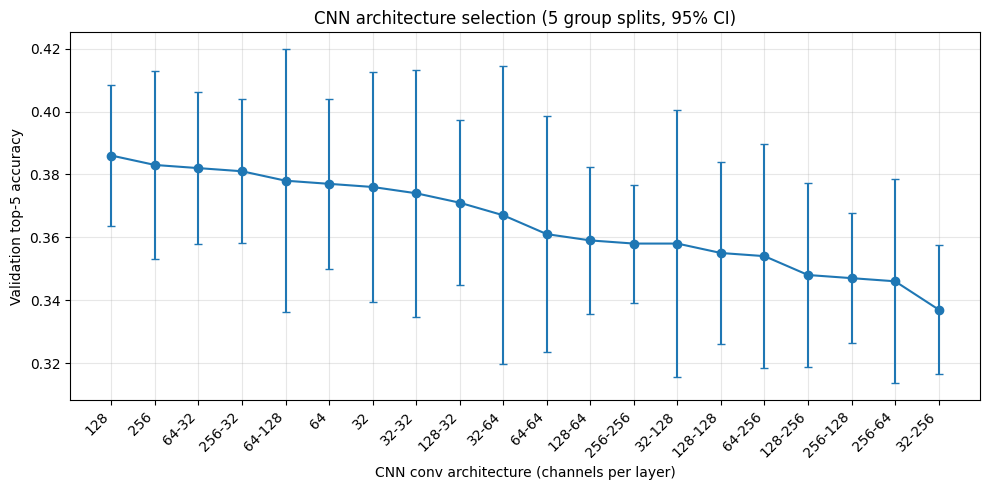

In [29]:
import matplotlib.pyplot as plt

# Sort by mean accuracy (descending)
df_ranked = arch_results_cnn_df.sort_values("val_top5_mean", ascending=False).reset_index(drop=True)

K = min(20, len(df_ranked))  # only plot top 20 to keep it readable
df_plot = df_ranked.iloc[:K].copy()

x = np.arange(len(df_plot))
means = df_plot["val_top5_mean"].values
ses = df_plot["val_top5_se"].values
ci95 = 1.96 * ses
labels = df_plot["arch_name"].tolist()

plt.figure(figsize=(10, 5))
plt.errorbar(
    x,
    means,
    yerr=ci95,
    marker="o",
    linestyle="-",
    capsize=3,
)
plt.xticks(x, labels, rotation=45, ha="right")
plt.xlabel("CNN conv architecture (channels per layer)")
plt.ylabel("Validation top-5 accuracy")
plt.title("CNN architecture selection (5 group splits, 95% CI)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [30]:
best_arch = df_ranked.iloc[0]
print("Best CNN arch:", best_arch["arch_name"])

Best CNN arch: 128


## Testing

### Logistic Reg

In [24]:
import chess
import numpy as np
import pandas as pd

# 1) Load test file
df_test = pd.read_csv(TEST_PATH)
print("Test rows:", len(df_test))
MOVE_COL = "best"

Test rows: 5012


In [33]:
import numpy as np
import pandas as pd
import chess
import chess.engine

def find_move_column(df):
    for c in ["move","Move","best_move","bestMove","solution","Solution","answer","Answer"]:
        if c in df.columns:
            return c
    raise ValueError(f"Move column not found. Columns: {list(df.columns)}")

def parse_csv_move(board, move_str):
    s = str(move_str).strip()
    try:
        return chess.Move.from_uci(s)
    except Exception:
        return board.parse_san(s)

def score_to_cp(score, mate_cap=100000):
    if score.is_mate():
        m = score.mate()
        return mate_cap if (m is not None and m > 0) else -mate_cap
    return score.cp

def eval_move_cp(board, move, engine, depth=12, mate_cap=100000):
    orig_turn = board.turn
    board.push(move)
    info = engine.analyse(board, chess.engine.Limit(depth=depth))
    cp = score_to_cp(info["score"].pov(orig_turn), mate_cap=mate_cap)
    board.pop()
    return cp

def evaluate_logreg_csv_cp_gap(model, df_test, fen_col, engine, depth=12, mate_cap=100000, k=5, move_col=None):
    if move_col is None:
        move_col = find_move_column(df_test)

    used = 0
    skipped = 0
    top1_correct = 0
    topk_correct = 0

    diffs = []        # signed: cp_correct - cp_model
    penalties = []    # nonnegative: max(0, diff)

    for _, row in df_test.iterrows():
        board = chess.Board(row[fen_col])

        try:
            correct_move = parse_csv_move(board, row[move_col])
        except Exception:
            skipped += 1
            continue

        legal = list(board.legal_moves)
        if correct_move not in legal:
            skipped += 1
            continue

        # model top-1 (rank by P(y=1))
        X_pos = np.vstack([extract_move_features(board, mv) for mv in legal])
        probs = model.predict_proba(X_pos)[:, 1]
        order = np.argsort(-probs)
        model_move = legal[int(order[0])]

        used += 1
        if model_move == correct_move:
            top1_correct += 1
        if correct_move in {legal[i] for i in order[:k]}:
            topk_correct += 1

        # cp scoring for both moves (same POV + same depth)
        cp_correct = eval_move_cp(board, correct_move, engine, depth=depth, mate_cap=mate_cap)
        cp_model = eval_move_cp(board, model_move, engine, depth=depth, mate_cap=mate_cap)

        d = float(cp_correct - cp_model)
        diffs.append(d)
        penalties.append(max(0.0, d))

    diffs = np.array(diffs, dtype=np.float64)
    penalties = np.array(penalties, dtype=np.float64)

    # 95% CI
    def mean_ci(x):
        m = x.mean()
        se = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan
        return m, m - 1.96 * se, m + 1.96 * se

    mean_diff, diff_lo, diff_hi = mean_ci(diffs)
    mean_pen, pen_lo, pen_hi = mean_ci(penalties)

    return {
        "move_col": move_col,
        "n_positions": used,
        "n_skipped": skipped,
        "top1_acc": top1_correct / used if used else np.nan,
        "top5_acc": topk_correct / used if used else np.nan,
        "mean_cp_gap": mean_diff,                 # signed mean gap
        "cp_gap_ci_low": diff_lo,
        "cp_gap_ci_high": diff_hi,
        "mean_cp_loss": mean_pen,                 # nonnegative penalty mean
        "cp_loss_ci_low": pen_lo,
        "cp_loss_ci_high": pen_hi,
        "frac_model_better": float(np.mean(diffs < 0)) if used else np.nan,
        "depth": depth,
        "mate_cap": mate_cap,
    }



In [25]:
X_test, pos_test, y_best_test, MOVE_COL, skipped = build_test_arrays_from_csv(
    df_test=df_test,
    fen_col=FEN_COL,
    move_col=None  # auto-detect
)

print("Detected MOVE_COL:", MOVE_COL)
print("Skipped positions:", skipped)
print("X_test shape:", X_test.shape)
print("Unique test positions used:", len(np.unique(pos_test)))
print("Positives in y_best_test (should equal positions used):", int(y_best_test.sum()))

Detected MOVE_COL: best
Skipped positions: 0
X_test shape: (191800, 25)
Unique test positions used: 5012
Positives in y_best_test (should equal positions used): 5012


In [30]:
def score_to_cp(score, mate_cap=100000):
    # score is PovScore after calling .pov(...)
    if score.is_mate():
        m = score.mate()
        return mate_cap if (m is not None and m > 0) else -mate_cap
    return score.cp

def eval_move_cp(board, move, engine, depth=12, mate_cap=100000):
    orig_turn = board.turn
    board.push(move)
    info = engine.analyse(board, chess.engine.Limit(depth=depth))
    score = info["score"].pov(orig_turn)
    board.pop()
    return score_to_cp(score, mate_cap=mate_cap)


In [12]:
from sklearn.linear_model import LogisticRegression

log_reg_best = LogisticRegression(
    penalty="l2",
    C=0.01,
    max_iter=1000,
    class_weight="balanced",
    solver="liblinear",
)

log_reg_best.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [37]:
def evaluate_logreg_csv_with_cp_loss(
    model, df_test, fen_col, engine, depth=12, k=5, move_col=None, mate_cap=100000
):
    if move_col is None:
        move_col = find_move_column(df_test)

    n_used = 0
    n_skipped = 0
    top1_correct = 0
    topk_correct = 0
    cp_losses = []

    for _, row in df_test.iterrows():
        board = chess.Board(row[fen_col])

        # CSV correct move
        try:
            true_move = parse_csv_move(board, row[move_col])
        except Exception:
            n_skipped += 1
            continue

        legal_moves = list(board.legal_moves)
        if true_move not in legal_moves:
            n_skipped += 1
            continue

        # model picks move by highest P(y=1)
        X_pos = np.vstack([extract_move_features(board, mv) for mv in legal_moves])
        probs = model.predict_proba(X_pos)[:, 1]
        order = np.argsort(-probs)

        chosen_move = legal_moves[int(order[0])]
        topk_moves = {legal_moves[i] for i in order[:k]}

        n_used += 1
        if chosen_move == true_move:
            top1_correct += 1
        if true_move in topk_moves:
            topk_correct += 1

        # centipawn loss relative to CSV move (not engine-best)
        cp_csv = eval_move_cp(board, true_move, engine, depth=depth, mate_cap=mate_cap)
        cp_model = eval_move_cp(board, chosen_move, engine, depth=depth, mate_cap=mate_cap)
        cp_losses.append(cp_csv - cp_model)

    cp_losses = np.array(cp_losses, dtype=np.float64)

    top1 = top1_correct / n_used if n_used else np.nan
    topk_acc = topk_correct / n_used if n_used else np.nan

    mean_loss = cp_losses.mean() if n_used else np.nan
    se = cp_losses.std(ddof=1) / np.sqrt(len(cp_losses)) if len(cp_losses) > 1 else np.nan
    ci_low = mean_loss - 1.96 * se if len(cp_losses) > 1 else np.nan
    ci_high = mean_loss + 1.96 * se if len(cp_losses) > 1 else np.nan

    return {
        "move_col": move_col,
        "n_positions": n_used,
        "n_skipped": n_skipped,
        "top1_acc": top1,
        "topk_acc": topk_acc,
        "mean_cp_loss": mean_loss,
        "cp_loss_ci_low": ci_low,
        "cp_loss_ci_high": ci_high,
        "k": k,
        "depth": depth,
        "mate_cap": mate_cap,
    }


In [38]:
log_csv_cp = evaluate_logreg_csv_cp_gap(
    model=log_reg_best,
    df_test=df_test,
    fen_col=FEN_COL,
    move_col=MOVE_COL,
    engine=engine,
    depth=3,
    mate_cap=100000,
    k=5
)

print("Logistic regression – CSV test (cp gap between model top-1 and CSV move)")
print(f"  Positions used:      {log_csv_cp['n_positions']}")
print(f"  Positions skipped:   {log_csv_cp['n_skipped']}")
print(f"  Top-1 accuracy:      {log_csv_cp['top1_acc']:.4f}")
print(f"  Top-5 accuracy:      {log_csv_cp['top5_acc']:.4f}")
print(f"  Mean cp gap (CSV - model): {log_csv_cp['mean_cp_gap']:.2f} cp  "
      f"[{log_csv_cp['cp_gap_ci_low']:.2f}, {log_csv_cp['cp_gap_ci_high']:.2f}]")
print(f"  Mean cp loss (max(0, gap)): {log_csv_cp['mean_cp_loss']:.2f} cp  "
      f"[{log_csv_cp['cp_loss_ci_low']:.2f}, {log_csv_cp['cp_loss_ci_high']:.2f}]")
print(f"  Fraction model better than CSV (gap < 0): {log_csv_cp['frac_model_better']:.3f}")

Logistic regression – CSV test (cp gap between model top-1 and CSV move)
  Positions used:      5012
  Positions skipped:   0
  Top-1 accuracy:      0.4044
  Top-5 accuracy:      0.8957
  Mean cp gap (CSV - model): -64122.08 cp  [-65686.46, -62557.70]
  Mean cp loss (max(0, gap)): 0.00 cp  [0.00, 0.00]
  Fraction model better than CSV (gap < 0): 0.596


### Ridge Reg

In [39]:
from sklearn.linear_model import RidgeClassifier

ridge_best = RidgeClassifier(alpha=0.001)
ridge_best.fit(X, y)


,alpha,0.001
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,class_weight,None
,solver,'auto'
,positive,False
,random_state,None


In [40]:
import numpy as np
import chess

def evaluate_ridge_csv_cp_gap(model, df_test, fen_col, engine, depth=12, mate_cap=100000, k=5, move_col=None):
    if move_col is None:
        move_col = find_move_column(df_test)

    used = 0
    skipped = 0
    top1_correct = 0
    topk_correct = 0

    diffs = []        # signed: cp_CSV - cp_model
    penalties = []    # nonnegative: max(0, diff)

    for _, row in df_test.iterrows():
        board = chess.Board(row[fen_col])

        try:
            correct_move = parse_csv_move(board, row[move_col])
        except Exception:
            skipped += 1
            continue

        legal = list(board.legal_moves)
        if correct_move not in legal:
            skipped += 1
            continue

        # Ridge ranking: decision_function scores (higher => more likely class 1)
        X_pos = np.vstack([extract_move_features(board, mv) for mv in legal])
        scores = model.decision_function(X_pos)  # shape (n_moves,)
        order = np.argsort(-scores)

        model_move = legal[int(order[0])]

        used += 1
        if model_move == correct_move:
            top1_correct += 1
        if correct_move in {legal[i] for i in order[:k]}:
            topk_correct += 1

        # cp scoring for both moves (same depth + same POV)
        cp_csv = eval_move_cp(board, correct_move, engine, depth=depth, mate_cap=mate_cap)
        cp_model = eval_move_cp(board, model_move, engine, depth=depth, mate_cap=mate_cap)

        d = float(cp_csv - cp_model)
        diffs.append(d)
        penalties.append(max(0.0, d))

    diffs = np.array(diffs, dtype=np.float64)
    penalties = np.array(penalties, dtype=np.float64)

    def mean_ci(x):
        m = x.mean()
        se = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan
        return m, m - 1.96 * se, m + 1.96 * se

    mean_diff, diff_lo, diff_hi = mean_ci(diffs)
    mean_pen, pen_lo, pen_hi = mean_ci(penalties)

    return {
        "move_col": move_col,
        "n_positions": used,
        "n_skipped": skipped,
        "top1_acc": top1_correct / used if used else np.nan,
        "top5_acc": topk_correct / used if used else np.nan,
        "mean_cp_gap": mean_diff,
        "cp_gap_ci_low": diff_lo,
        "cp_gap_ci_high": diff_hi,
        "mean_cp_loss": mean_pen,
        "cp_loss_ci_low": pen_lo,
        "cp_loss_ci_high": pen_hi,
        "frac_model_better": float(np.mean(diffs < 0)) if used else np.nan,
        "depth": depth,
        "mate_cap": mate_cap,
    }

In [43]:
import pandas as pd

ridge_res = evaluate_ridge_csv_cp_gap(
    model=ridge_best,
    df_test=df_test,
    fen_col=FEN_COL,
    move_col=MOVE_COL,
    engine=engine,
    depth=12,
    mate_cap=100000,
    k=5
)

print("Ridge classifier – CSV test (cp gap between model top-1 and CSV move)")
print(f"  Positions used:      {ridge_res['n_positions']}")
print(f"  Positions skipped:   {ridge_res['n_skipped']}")
print(f"  Top-1 accuracy:      {ridge_res['top1_acc']:.4f}")
print(f"  Top-5 accuracy:      {ridge_res['top5_acc']:.4f}")
print(f"  Mean cp gap (CSV - model): {ridge_res['mean_cp_gap']:.2f} cp  "
      f"[{ridge_res['cp_gap_ci_low']:.2f}, {ridge_res['cp_gap_ci_high']:.2f}]")
print(f"  Mean cp loss (max(0, gap)): {ridge_res['mean_cp_loss']:.2f} cp  "
      f"[{ridge_res['cp_loss_ci_low']:.2f}, {ridge_res['cp_loss_ci_high']:.2f}]")
print(f"  Fraction model better than CSV (gap < 0): {ridge_res['frac_model_better']:.3f}")


Ridge classifier – CSV test (cp gap between model top-1 and CSV move)
  Positions used:      5012
  Positions skipped:   0
  Top-1 accuracy:      0.4064
  Top-5 accuracy:      0.8887
  Mean cp gap (CSV - model): -75026.27 cp  [-76988.60, -73063.94]
  Mean cp loss (max(0, gap)): 0.00 cp  [0.00, 0.00]
  Fraction model better than CSV (gap < 0): 0.592


### Linear SVM

In [49]:
def eval_move_cp(board, move, engine, depth=4, mate_cap=100000):
    orig_turn = board.turn
    board.push(move)

    # If this move delivers checkmate, it is maximally good for the mover.
    if board.is_checkmate():
        board.pop()
        return mate_cap

    info = engine.analyse(board, chess.engine.Limit(depth=depth))
    score = info["score"].pov(orig_turn)
    board.pop()

    if score.is_mate():
        m = score.mate()
        return mate_cap if (m is not None and m > 0) else -mate_cap
    return score.cp


In [50]:
from sklearn.svm import LinearSVC

svm_lin_best = LinearSVC(C=1.0, class_weight="balanced", max_iter=10000)
svm_lin_best.fit(X, y)


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,None


In [51]:
import numpy as np
import pandas as pd
import chess

def evaluate_linearsvm_csv_cp_gap(model, df_test, fen_col, engine, depth=12, mate_cap=100000, k=5, move_col=None):
    if move_col is None:
        move_col = find_move_column(df_test)

    used = 0
    skipped = 0
    top1_correct = 0
    topk_correct = 0

    diffs = []        # signed: cp_CSV - cp_model
    penalties = []    # nonnegative: max(0, diff)

    for _, row in df_test.iterrows():
        board = chess.Board(row[fen_col])

        try:
            correct_move = parse_csv_move(board, row[move_col])
        except Exception:
            skipped += 1
            continue

        legal = list(board.legal_moves)
        if correct_move not in legal:
            skipped += 1
            continue

        # LinearSVC ranking uses decision_function (higher score => more positive)
        X_pos = np.vstack([extract_move_features(board, mv) for mv in legal])
        scores = model.decision_function(X_pos)
        order = np.argsort(-scores)
        model_move = legal[int(order[0])]

        used += 1
        if model_move == correct_move:
            top1_correct += 1
        if correct_move in {legal[i] for i in order[:k]}:
            topk_correct += 1

        cp_csv = eval_move_cp(board, correct_move, engine, depth=depth, mate_cap=mate_cap)
        cp_model = eval_move_cp(board, model_move, engine, depth=depth, mate_cap=mate_cap)

        d = float(cp_csv - cp_model)
        diffs.append(d)
        penalties.append(max(0.0, d))

    diffs = np.array(diffs, dtype=np.float64)
    penalties = np.array(penalties, dtype=np.float64)

    def mean_ci(x):
        m = x.mean()
        se = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan
        return m, m - 1.96 * se, m + 1.96 * se

    mean_diff, diff_lo, diff_hi = mean_ci(diffs)
    mean_pen, pen_lo, pen_hi = mean_ci(penalties)

    return {
        "move_col": move_col,
        "n_positions": used,
        "n_skipped": skipped,
        "top1_acc": top1_correct / used if used else np.nan,
        "top5_acc": topk_correct / used if used else np.nan,
        "mean_cp_gap": mean_diff,
        "cp_gap_ci_low": diff_lo,
        "cp_gap_ci_high": diff_hi,
        "mean_cp_loss": mean_pen,
        "cp_loss_ci_low": pen_lo,
        "cp_loss_ci_high": pen_hi,
        "frac_model_better": float(np.mean(diffs < 0)) if used else np.nan,
        "depth": depth,
        "mate_cap": mate_cap,
    }


In [52]:
lin_svm_res = evaluate_linearsvm_csv_cp_gap(
    model=svm_lin_best,
    df_test=df_test,
    fen_col=FEN_COL,
    move_col=MOVE_COL,
    engine=engine,
    depth=12,
    mate_cap=100000,
    k=5
)

print("Linear SVM – CSV test (cp gap between model top-1 and CSV move)")
print(f"  Positions used:      {lin_svm_res['n_positions']}")
print(f"  Positions skipped:   {lin_svm_res['n_skipped']}")
print(f"  Top-1 accuracy:      {lin_svm_res['top1_acc']:.4f}")
print(f"  Top-5 accuracy:      {lin_svm_res['top5_acc']:.4f}")
print(f"  Mean cp gap (CSV - model): {lin_svm_res['mean_cp_gap']:.2f} cp  "
      f"[{lin_svm_res['cp_gap_ci_low']:.2f}, {lin_svm_res['cp_gap_ci_high']:.2f}]")
print(f"  Mean cp loss (max(0, gap)): {lin_svm_res['mean_cp_loss']:.2f} cp  "
      f"[{lin_svm_res['cp_loss_ci_low']:.2f}, {lin_svm_res['cp_loss_ci_high']:.2f}]")
print(f"  Fraction model better than CSV (gap < 0): {lin_svm_res['frac_model_better']:.3f}")


Linear SVM – CSV test (cp gap between model top-1 and CSV move)
  Positions used:      5012
  Positions skipped:   0
  Top-1 accuracy:      0.3992
  Top-5 accuracy:      0.8939
  Mean cp gap (CSV - model): 44107.68 cp  [42729.71, 45485.64]
  Mean cp loss (max(0, gap)): 44107.68 cp  [42729.71, 45485.64]
  Fraction model better than CSV (gap < 0): 0.000


### RBF SMV

In [10]:
def evaluate_rbf_svm_top1_cp_loss(model, X_test, pos_test, y_best_test, cp_true_test):
    # scores for each move (higher => more likely class 1 = best move)
    scores = model.decision_function(X_test)  # shape (N_moves,) for binary SVC

    pos_test = np.asarray(pos_test)
    y_best_test = np.asarray(y_best_test)
    cp_true_test = np.asarray(cp_true_test)

    unique_positions = np.unique(pos_test)

    correct_top1 = 0
    cp_losses = []

    for pid in unique_positions:
        idxs = np.where(pos_test == pid)[0]
        if len(idxs) == 0:
            continue

        # ground-truth best move in this position
        pos_y = y_best_test[idxs]
        best_local_idxs = np.where(pos_y == 1)[0]
        if len(best_local_idxs) != 1:
            # Fallback: derive best from cp_true if labels aren’t exactly one-hot
            best_local = int(np.argmax(cp_true_test[idxs]))
        else:
            best_local = int(best_local_idxs[0])

        global_best_idx = idxs[best_local]

        # model-chosen move: max score from decision_function
        pos_scores = scores[idxs]
        pred_local = int(np.argmax(pos_scores))
        global_pred_idx = idxs[pred_local]

        # top-1 accuracy
        if global_best_idx == global_pred_idx:
            correct_top1 += 1

        # centipawn loss = cp(best true) - cp(true of chosen)
        cp_best_true = cp_true_test[global_best_idx]
        cp_chosen_true = cp_true_test[global_pred_idx]
        cp_loss = cp_best_true - cp_chosen_true
        if cp_loss < 0:
            cp_loss = 0.0  # guard against tiny negative noise

        cp_losses.append(cp_loss)

    n_positions = len(unique_positions)
    top1_acc = correct_top1 / n_positions

    cp_losses = np.array(cp_losses, dtype=np.float64)
    mean_cp_loss = cp_losses.mean()
    se = cp_losses.std(ddof=1) / np.sqrt(len(cp_losses))
    ci_low = mean_cp_loss - 1.96 * se
    ci_high = mean_cp_loss + 1.96 * se

    return {
        "n_positions": n_positions,
        "top1_acc": top1_acc,
        "mean_cp_loss": mean_cp_loss,
        "cp_loss_ci_low": ci_low,
        "cp_loss_ci_high": ci_high,
    }


In [11]:
from sklearn.svm import SVC

svm_rbf_best = SVC(
    kernel="rbf",
    C=100,
    gamma=1,
    class_weight="balanced",
)
svm_rbf_best.fit(X, y)   # or X_train_full, y_train_full

# then same evaluation call as above
rbf_test_results = evaluate_rbf_svm_top1_cp_loss(
    model=svm_rbf_best,
    X_test=X_test,
    pos_test=pos_test,
    y_best_test=y_best_test,
    cp_true_test=cp_true_test,
)

print("RBF SVM (SVC, C=100, gamma=1) – TEST performance")
print(f"  Positions:         {rbf_test_results['n_positions']}")
print(f"  Top-1 accuracy:    {rbf_test_results['top1_acc']:.4f}")
print(f"  Mean cp loss:      {rbf_test_results['mean_cp_loss']:.2f} cp")
print(
    "  95% CI (cp loss):  "
    f"[{rbf_test_results['cp_loss_ci_low']:.2f}, "
    f"{rbf_test_results['cp_loss_ci_high']:.2f}] cp"
)

RBF SVM (SVC, C=100, gamma=1) – TEST performance
  Positions:         5012
  Top-1 accuracy:    0.0794
  Mean cp loss:      69199.46 cp
  95% CI (cp loss):  [67359.55, 71039.37] cp


In [53]:
import numpy as np
import pandas as pd
import chess
import chess.engine

def score_to_cp(score, mate_cap=100000):
    if score.is_mate():
        m = score.mate()
        return mate_cap if (m is not None and m > 0) else -mate_cap
    return score.cp

def eval_move_cp_fast(board, move, engine, depth=12, mate_cap=100000):
    orig_turn = board.turn
    board.push(move)

    if board.is_checkmate():          # mate-in-one terminal
        board.pop()
        return mate_cap

    info = engine.analyse(board, chess.engine.Limit(depth=depth))
    score = info["score"].pov(orig_turn)
    board.pop()
    return score_to_cp(score, mate_cap=mate_cap)

def evaluate_rbfsvm_csv_cp_gap_fast(model, df_test, fen_col, engine, depth=12, mate_cap=100000, k=5, move_col=None, report_every=250):
    if move_col is None:
        move_col = find_move_column(df_test)

    used = 0
    skipped = 0
    top1_correct = 0
    topk_correct = 0

    gaps = []      # signed: cp_CSV - cp_model
    losses = []    # nonnegative: max(0, gap)

    for i, (_, row) in enumerate(df_test.iterrows(), 1):
        board = chess.Board(row[fen_col])

        # CSV correct move
        try:
            correct_move = parse_csv_move(board, row[move_col])
        except Exception:
            skipped += 1
            continue

        legal = list(board.legal_moves)
        if correct_move not in legal:
            skipped += 1
            continue

        # Rank by decision_function (SVC without probability is faster)
        X_pos = np.vstack([extract_move_features(board, mv) for mv in legal])
        scores = model.decision_function(X_pos)
        order = np.argsort(-scores)
        model_move = legal[int(order[0])]

        used += 1
        if model_move == correct_move:
            top1_correct += 1
        if correct_move in {legal[j] for j in order[:k]}:
            topk_correct += 1

        # If same move, gap/loss = 0 without any engine calls
        if model_move == correct_move:
            gaps.append(0.0)
            losses.append(0.0)
        else:
            # cp for CSV move (usually mate => no engine call)
            cp_csv = eval_move_cp_fast(board, correct_move, engine, depth=depth, mate_cap=mate_cap)

            # cp for model move (engine call only if not checkmate)
            cp_model = eval_move_cp_fast(board, model_move, engine, depth=depth, mate_cap=mate_cap)

            gap = float(cp_csv - cp_model)
            gaps.append(gap)
            losses.append(max(0.0, gap))

        if report_every and (i % report_every == 0):
            print(f"Processed {i}/{len(df_test)} positions...")

    gaps = np.array(gaps, dtype=np.float64)
    losses = np.array(losses, dtype=np.float64)

    def mean_ci(x):
        m = x.mean()
        se = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan
        return m, m - 1.96 * se, m + 1.96 * se

    mean_gap, gap_lo, gap_hi = mean_ci(gaps)
    mean_loss, loss_lo, loss_hi = mean_ci(losses)

    return {
        "move_col": move_col,
        "n_positions": used,
        "n_skipped": skipped,
        "top1_acc": top1_correct / used if used else np.nan,
        "top5_acc": topk_correct / used if used else np.nan,
        "mean_cp_gap": mean_gap,
        "cp_gap_ci_low": gap_lo,
        "cp_gap_ci_high": gap_hi,
        "mean_cp_loss": mean_loss,
        "cp_loss_ci_low": loss_lo,
        "cp_loss_ci_high": loss_hi,
        "frac_model_better": float(np.mean(gaps < 0)) if used else np.nan,
        "depth": depth,
        "mate_cap": mate_cap,
    }


In [54]:
rbf_res = evaluate_rbfsvm_csv_cp_gap_fast(
    model=svm_rbf_best,
    df_test=df_test,
    fen_col=FEN_COL,
    move_col=MOVE_COL,
    engine=engine,
    depth=12,
    mate_cap=100000,
    k=5,
    report_every=250
)

print("RBF SVM – CSV test (cp gap between model top-1 and CSV move)")
print(f"  Positions used:      {rbf_res['n_positions']}")
print(f"  Positions skipped:   {rbf_res['n_skipped']}")
print(f"  Top-1 accuracy:      {rbf_res['top1_acc']:.4f}")
print(f"  Top-5 accuracy:      {rbf_res['top5_acc']:.4f}")
print(f"  Mean cp gap (CSV - model): {rbf_res['mean_cp_gap']:.2f} cp  "
      f"[{rbf_res['cp_gap_ci_low']:.2f}, {rbf_res['cp_gap_ci_high']:.2f}]")
print(f"  Mean cp loss (max(0, gap)): {rbf_res['mean_cp_loss']:.2f} cp  "
      f"[{rbf_res['cp_loss_ci_low']:.2f}, {rbf_res['cp_loss_ci_high']:.2f}]")
print(f"  Fraction model better than CSV (gap < 0): {rbf_res['frac_model_better']:.3f}")

Processed 250/5012 positions...
Processed 500/5012 positions...
Processed 750/5012 positions...
Processed 1000/5012 positions...
Processed 1250/5012 positions...
Processed 1500/5012 positions...
Processed 1750/5012 positions...
Processed 2000/5012 positions...
Processed 2250/5012 positions...
Processed 2500/5012 positions...
Processed 2750/5012 positions...
Processed 3000/5012 positions...
Processed 3250/5012 positions...
Processed 3500/5012 positions...
Processed 3750/5012 positions...
Processed 4000/5012 positions...
Processed 4250/5012 positions...
Processed 4500/5012 positions...
Processed 4750/5012 positions...
Processed 5000/5012 positions...
RBF SVM – CSV test (cp gap between model top-1 and CSV move)
  Positions used:      5012
  Positions skipped:   0
  Top-1 accuracy:      0.3065
  Top-5 accuracy:      0.8655
  Mean cp gap (CSV - model): 52518.65 cp  [51126.45, 53910.86]
  Mean cp loss (max(0, gap)): 52518.65 cp  [51126.45, 53910.86]
  Fraction model better than CSV (gap < 0)

### MLP

In [55]:
import numpy as np
import pandas as pd
import chess

def build_move_level_arrays_from_csv(df, fen_col, move_col):
    X_list, pos_list, y_list = [], [], []
    skipped = 0

    for pos_idx, row in df.iterrows():
        board = chess.Board(row[fen_col])
        try:
            correct_move = parse_csv_move(board, row[move_col])
        except Exception:
            skipped += 1
            continue

        legal = list(board.legal_moves)
        if correct_move not in legal:
            skipped += 1
            continue

        for mv in legal:
            X_list.append(extract_move_features(board, mv))
            pos_list.append(pos_idx)
            y_list.append(1 if mv == correct_move else 0)

    X = np.vstack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int64)
    pos = np.array(pos_list, dtype=np.int64)
    return X, y, pos, skipped


In [56]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class MLP(nn.Module):
    def __init__(self, d_in, hidden1=256, hidden2=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 1)  # binary logit
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def train_mlp_binary(
    X, y,
    hidden1=256, hidden2=128,
    dropout=0.2,
    lr=1e-2,
    weight_decay=0.0,
    batch_size=2048,
    epochs=10
):
    X_t = torch.from_numpy(X)
    y_t = torch.from_numpy(y).float()

    ds = TensorDataset(X_t, y_t)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)

    model = MLP(d_in=X.shape[1], hidden1=hidden1, hidden2=hidden2, dropout=dropout).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss()

    model.train()
    for ep in range(1, epochs + 1):
        tot = 0.0
        n = 0
        for xb, yb in dl:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()

            tot += float(loss.item()) * len(xb)
            n += len(xb)

        print(f"Epoch {ep:02d} | train BCE: {tot/n:.4f}")

    return model


In [57]:
mlp_best = train_mlp_binary(
    X_train, y_train,
    hidden1=256, hidden2=128,
    dropout=0.2,
    lr=1e-2,
    weight_decay=0.0,
    batch_size=2048,
    epochs=10
)

Epoch 01 | train BCE: 0.0662
Epoch 02 | train BCE: 0.0602
Epoch 03 | train BCE: 0.0600
Epoch 04 | train BCE: 0.0599
Epoch 05 | train BCE: 0.0599
Epoch 06 | train BCE: 0.0599
Epoch 07 | train BCE: 0.0599
Epoch 08 | train BCE: 0.0599
Epoch 09 | train BCE: 0.0599
Epoch 10 | train BCE: 0.0598


In [58]:
def mlp_scores(model, X, batch_size=8192):
    model.eval()
    scores = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.from_numpy(X[i:i+batch_size]).to(DEVICE)
            logits = model(xb)
            scores.append(logits.detach().cpu().numpy())
    return np.concatenate(scores, axis=0)


In [59]:
def eval_move_cp_fast(board, move, engine, depth=4, mate_cap=100000):
    orig_turn = board.turn
    board.push(move)
    if board.is_checkmate():
        board.pop()
        return mate_cap
    info = engine.analyse(board, chess.engine.Limit(depth=depth))
    score = info["score"].pov(orig_turn)
    board.pop()
    return score_to_cp(score, mate_cap=mate_cap)

def evaluate_mlp_csv_cp_gap(
    model, df_test, fen_col, engine, depth=12, mate_cap=100000, k=5, move_col=None
):
    if move_col is None:
        move_col = find_move_column(df_test)

    used = 0
    skipped = 0
    top1_correct = 0
    topk_correct = 0
    gaps = []
    losses = []

    for _, row in df_test.iterrows():
        board = chess.Board(row[fen_col])
        try:
            correct_move = parse_csv_move(board, row[move_col])
        except Exception:
            skipped += 1
            continue

        legal = list(board.legal_moves)
        if correct_move not in legal:
            skipped += 1
            continue

        X_pos = np.vstack([extract_move_features(board, mv) for mv in legal]).astype(np.float32)

        # MLP ranking by logit score
        pos_scores = mlp_scores(model, X_pos, batch_size=4096)
        order = np.argsort(-pos_scores)
        model_move = legal[int(order[0])]

        used += 1
        if model_move == correct_move:
            top1_correct += 1
        if correct_move in {legal[i] for i in order[:k]}:
            topk_correct += 1

        if model_move == correct_move:
            gaps.append(0.0)
            losses.append(0.0)
        else:
            cp_csv = eval_move_cp_fast(board, correct_move, engine, depth=depth, mate_cap=mate_cap)
            cp_model = eval_move_cp_fast(board, model_move, engine, depth=depth, mate_cap=mate_cap)
            gap = float(cp_csv - cp_model)
            gaps.append(gap)
            losses.append(max(0.0, gap))

    gaps = np.array(gaps, dtype=np.float64)
    losses = np.array(losses, dtype=np.float64)

    def mean_ci(x):
        m = x.mean()
        se = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan
        return m, m - 1.96 * se, m + 1.96 * se

    mean_gap, gap_lo, gap_hi = mean_ci(gaps)
    mean_loss, loss_lo, loss_hi = mean_ci(losses)

    return {
        "n_positions": used,
        "n_skipped": skipped,
        "top1_acc": top1_correct / used if used else np.nan,
        "top5_acc": topk_correct / used if used else np.nan,
        "mean_cp_gap": mean_gap,
        "cp_gap_ci_low": gap_lo,
        "cp_gap_ci_high": gap_hi,
        "mean_cp_loss": mean_loss,
        "cp_loss_ci_low": loss_lo,
        "cp_loss_ci_high": loss_hi,
        "frac_model_better": float(np.mean(gaps < 0)) if used else np.nan,
    }


In [60]:
mlp_res = evaluate_mlp_csv_cp_gap(
    model=mlp_best,
    df_test=df_test,
    fen_col=FEN_COL,
    move_col=MOVE_COL,
    engine=engine,
    depth=4,
    mate_cap=100000,
    k=5
)

print("MLP – CSV test (cp gap between model top-1 and CSV move)")
print(f"  Positions used:      {mlp_res['n_positions']}")
print(f"  Positions skipped:   {mlp_res['n_skipped']}")
print(f"  Top-1 accuracy:      {mlp_res['top1_acc']:.4f}")
print(f"  Top-5 accuracy:      {mlp_res['top5_acc']:.4f}")
print(f"  Mean cp gap (CSV - model): {mlp_res['mean_cp_gap']:.2f} cp  "
      f"[{mlp_res['cp_gap_ci_low']:.2f}, {mlp_res['cp_gap_ci_high']:.2f}]")
print(f"  Mean cp loss (max(0, gap)): {mlp_res['mean_cp_loss']:.2f} cp  "
      f"[{mlp_res['cp_loss_ci_low']:.2f}, {mlp_res['cp_loss_ci_high']:.2f}]")
print(f"  Fraction model better than CSV (gap < 0): {mlp_res['frac_model_better']:.3f}")


MLP – CSV test (cp gap between model top-1 and CSV move)
  Positions used:      5012
  Positions skipped:   0
  Top-1 accuracy:      0.3901
  Top-5 accuracy:      0.8901
  Mean cp gap (CSV - model): 56453.64 cp  [55086.64, 57820.65]
  Mean cp loss (max(0, gap)): 56453.64 cp  [55086.64, 57820.65]
  Fraction model better than CSV (gap < 0): 0.000


### CNN

In [61]:
import chess
import chess.engine

def score_to_cp(score, mate_cap=100000):
    if score.is_mate():
        m = score.mate()
        return mate_cap if (m is not None and m > 0) else -mate_cap
    return score.cp

def eval_move_cp(board, move, engine, depth=12, mate_cap=100000):
    orig_turn = board.turn
    board.push(move)

    # mate-in-one terminal handling
    if board.is_checkmate():
        board.pop()
        return mate_cap

    info = engine.analyse(board, chess.engine.Limit(depth=depth))
    cp = score_to_cp(info["score"].pov(orig_turn), mate_cap=mate_cap)
    board.pop()
    return cp


In [62]:
import numpy as np
import chess

def square_to_rc(sq):
    # a1 -> (7,0), h8 -> (0,7)
    return 7 - chess.square_rank(sq), chess.square_file(sq)

def build_move_planes(move):
    frm = np.zeros((8,8), dtype=np.float32)
    to  = np.zeros((8,8), dtype=np.float32)
    r1,c1 = square_to_rc(move.from_square)
    r2,c2 = square_to_rc(move.to_square)
    frm[r1,c1] = 1.0
    to[r2,c2]  = 1.0
    return frm, to

def board_to_17_planes(board):
    planes = np.zeros((17,8,8), dtype=np.float32)

    # Example: 12 piece planes (WP..WK, BP..BK), plus side-to-move, plus castling (4)
    piece_map = board.piece_map()
    piece_to_plane = {
        (chess.PAWN, True): 0, (chess.KNIGHT, True): 1, (chess.BISHOP, True): 2,
        (chess.ROOK, True): 3, (chess.QUEEN, True): 4, (chess.KING, True): 5,
        (chess.PAWN, False): 6, (chess.KNIGHT, False): 7, (chess.BISHOP, False): 8,
        (chess.ROOK, False): 9, (chess.QUEEN, False): 10, (chess.KING, False): 11,
    }
    for sq, pc in piece_map.items():
        r,c = square_to_rc(sq)
        planes[piece_to_plane[(pc.piece_type, pc.color)], r, c] = 1.0

    # side to move
    planes[12,:,:] = 1.0 if board.turn == chess.WHITE else 0.0

    # castling rights (WK, WQ, BK, BQ)
    planes[13,:,:] = 1.0 if board.has_kingside_castling_rights(chess.WHITE) else 0.0
    planes[14,:,:] = 1.0 if board.has_queenside_castling_rights(chess.WHITE) else 0.0
    planes[15,:,:] = 1.0 if board.has_kingside_castling_rights(chess.BLACK) else 0.0
    planes[16,:,:] = 1.0 if board.has_queenside_castling_rights(chess.BLACK) else 0.0

    return planes

def make_cnn_input_19(board, move):
    b17 = board_to_17_planes(board)
    frm, to = build_move_planes(move)
    x = np.concatenate([b17, frm[None,:,:], to[None,:,:]], axis=0)  # (19,8,8)
    return x.astype(np.float32)


In [80]:
import numpy as np
import pandas as pd
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def evaluate_cnn_csv_cp_gap(
    cnn_model, df_test, fen_col, engine, depth=4, mate_cap=100000, k=5, move_col=None,
    batch_size_moves=256
):
    if move_col is None:
        move_col = find_move_column(df_test)

    cnn_model.eval()
    cnn_model.to(DEVICE)

    used = 0
    skipped = 0
    top1_correct = 0
    topk_correct = 0
    gaps = []
    losses = []

    for _, row in df_test.iterrows():
        board = chess.Board(row[fen_col])

        try:
            correct_move = parse_csv_move(board, row[move_col])
        except Exception:
            skipped += 1
            continue

        legal = list(board.legal_moves)
        if correct_move not in legal:
            skipped += 1
            continue

        # Build tensors for all legal moves
        X_pos = np.stack([make_cnn_input_19(board, mv) for mv in legal], axis=0)  # (n,19,8,8)

        # Score all moves (logits), batched
        scores = []
        with torch.no_grad():
            for i in range(0, len(X_pos), batch_size_moves):
                xb = torch.from_numpy(X_pos[i:i+batch_size_moves]).to(DEVICE)
                logits = cnn_model(xb)

        # make shape (batch,) no matter what the model outputs
        logits = logits.reshape(-1)

        scores.append(logits.detach().cpu().numpy())

        scores = np.concatenate(scores, axis=0)

        order = np.argsort(-scores)
        model_move = legal[int(order[0])]
        used += 1

        if model_move == correct_move:
            top1_correct += 1
        if correct_move in {legal[i] for i in order[:k]}:
            topk_correct += 1

        if model_move == correct_move:
            gaps.append(0.0)
            losses.append(0.0)
        else:
            cp_csv = eval_move_cp(board, correct_move, engine, depth=depth, mate_cap=mate_cap)
            cp_model = eval_move_cp(board, model_move, engine, depth=depth, mate_cap=mate_cap)
            gap = float(cp_csv - cp_model)
            gaps.append(gap)
            losses.append(max(0.0, gap))

    gaps = np.array(gaps, dtype=np.float64)
    losses = np.array(losses, dtype=np.float64)

    def mean_ci(x):
        m = x.mean()
        se = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan
        return m, m - 1.96 * se, m + 1.96 * se

    mean_gap, gap_lo, gap_hi = mean_ci(gaps)
    mean_loss, loss_lo, loss_hi = mean_ci(losses)

    return {
        "n_positions": used,
        "n_skipped": skipped,
        "top1_acc": top1_correct / used if used else np.nan,
        "top5_acc": topk_correct / used if used else np.nan,
        "mean_cp_gap": mean_gap,
        "cp_gap_ci_low": gap_lo,
        "cp_gap_ci_high": gap_hi,
        "mean_cp_loss": mean_loss,
        "cp_loss_ci_low": loss_lo,
        "cp_loss_ci_high": loss_hi,
        "frac_model_better": float(np.mean(gaps < 0)) if used else np.nan,
    }


In [69]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, in_ch=19, conv_ch=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, conv_ch, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(conv_ch * 8 * 8, 1)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.head(x)
        return x.squeeze(-1)   # logits


[9]Bengal1, “GitHub - Bengal1/Simple-CNN-Guide: A beginner’s guide to building Convolutional Neural Networks (CNNs).,” GitHub, 2025. https://github.com/Bengal1/Simple-CNN-Guide (accessed Dec. 6, 2025).

In [71]:
import numpy as np
import pandas as pd
import chess

def square_to_rc(sq):
    return 7 - chess.square_rank(sq), chess.square_file(sq)  # a1->(7,0), h8->(0,7)

def board_to_17_planes(board):
    """
    17 planes:
      0-11: piece planes (WP,WN,WB,WR,WQ,WK, BP,BN,BB,BR,BQ,BK)
      12: side-to-move (all ones if White to move else zeros)
      13-16: castling rights (WK, WQ, BK, BQ) broadcasted
    """
    planes = np.zeros((17, 8, 8), dtype=np.float32)

    piece_to_plane = {
        (chess.PAWN, True): 0, (chess.KNIGHT, True): 1, (chess.BISHOP, True): 2,
        (chess.ROOK, True): 3, (chess.QUEEN, True): 4, (chess.KING, True): 5,
        (chess.PAWN, False): 6, (chess.KNIGHT, False): 7, (chess.BISHOP, False): 8,
        (chess.ROOK, False): 9, (chess.QUEEN, False): 10, (chess.KING, False): 11,
    }

    for sq, pc in board.piece_map().items():
        r, c = square_to_rc(sq)
        planes[piece_to_plane[(pc.piece_type, pc.color)], r, c] = 1.0

    planes[12, :, :] = 1.0 if board.turn == chess.WHITE else 0.0
    planes[13, :, :] = 1.0 if board.has_kingside_castling_rights(chess.WHITE) else 0.0
    planes[14, :, :] = 1.0 if board.has_queenside_castling_rights(chess.WHITE) else 0.0
    planes[15, :, :] = 1.0 if board.has_kingside_castling_rights(chess.BLACK) else 0.0
    planes[16, :, :] = 1.0 if board.has_queenside_castling_rights(chess.BLACK) else 0.0

    return planes

def move_to_2_planes(move):
    frm = np.zeros((8,8), dtype=np.float32)
    to  = np.zeros((8,8), dtype=np.float32)
    r1, c1 = square_to_rc(move.from_square)
    r2, c2 = square_to_rc(move.to_square)
    frm[r1, c1] = 1.0
    to[r2, c2]  = 1.0
    return frm, to

def make_cnn_input_19(board, move):
    b17 = board_to_17_planes(board)
    frm, to = move_to_2_planes(move)
    return np.concatenate([b17, frm[None,:,:], to[None,:,:]], axis=0)  # (19,8,8)


In [72]:
def build_cnn_move_dataset_from_csv(df, fen_col, move_col=None, limit_positions=None):
    if move_col is None:
        move_col = find_move_column(df)

    X_list, y_list, pos_list = [], [], []
    skipped = 0

    iterable = df.iterrows()
    if limit_positions is not None:
        iterable = list(iterable)[:limit_positions]

    for pos_idx, row in iterable:
        board = chess.Board(row[fen_col])

        try:
            correct_move = parse_csv_move(board, row[move_col])
        except Exception:
            skipped += 1
            continue

        legal_moves = list(board.legal_moves)
        if correct_move not in legal_moves:
            skipped += 1
            continue

        for mv in legal_moves:
            X_list.append(make_cnn_input_19(board, mv))
            y_list.append(1 if mv == correct_move else 0)
            pos_list.append(pos_idx)

    X = np.stack(X_list, axis=0).astype(np.float32)    # (N,19,8,8)
    y = np.array(y_list, dtype=np.int64)              # (N,)
    pos_id = np.array(pos_list, dtype=np.int64)       # (N,)

    return X, y, pos_id, skipped, move_col


In [76]:
import numpy as np
import pandas as pd
import chess

# 1) Get the first 1000 unique position
pos_ids_1000 = np.unique(pos_train)[:1000]

# 2) Load the corresponding 1000 positions from the training CSV
df_train = pd.read_csv(TRAIN_PATH)
df_sub = df_train.loc[pos_ids_1000].copy()

MOVE_COL = "best"

# 3) Build CNN tensors only for those 1000 positions
X_cnn_train, y_cnn_train, pos_id_cnn_train, skipped_train, _ = build_cnn_move_dataset_from_csv(
    df_sub,
    fen_col=FEN_COL,
    move_col=MOVE_COL,
    limit_positions=None
)

print("CNN TRAIN (first 1000 positions):")
print("  X_cnn_train:", X_cnn_train.shape)
print("  y_cnn_train:", y_cnn_train.shape, "positives:", int(y_cnn_train.sum()))
print("  unique positions:", len(np.unique(pos_id_cnn_train)))
print("  skipped:", skipped_train)


CNN TRAIN (first 1000 positions):
  X_cnn_train: (37951, 19, 8, 8)
  y_cnn_train: (37951,) positives: 1000
  unique positions: 1000
  skipped: 0


In [77]:
from torch.utils.data import TensorDataset, DataLoader

def train_cnn_binary(X_cnn, y, conv_ch=128, lr=1e-3, weight_decay=0.0, batch_size=256, epochs=5):
    model = SimpleCNN(in_ch=X_cnn.shape[1], conv_ch=conv_ch).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss()

    ds = TensorDataset(torch.from_numpy(X_cnn).float(), torch.from_numpy(y).float())
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)

    model.train()
    for ep in range(1, epochs + 1):
        tot, n = 0.0, 0
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            tot += float(loss.item()) * len(xb)
            n += len(xb)
        print(f"Epoch {ep:02d} | train BCE: {tot/n:.4f}")

    return model

cnn_best = train_cnn_binary(X_cnn_train, y_cnn_train, conv_ch=128)
cnn_best.eval()


Epoch 01 | train BCE: 0.1344
Epoch 02 | train BCE: 0.1142
Epoch 03 | train BCE: 0.1059
Epoch 04 | train BCE: 0.0981
Epoch 05 | train BCE: 0.0921


SimpleCNN(
  (conv): Sequential(
    (0): Conv2d(19, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=1, bias=True)
  )
)

In [78]:
print([name for name in globals() if "cnn" in name.lower()])

['make_cnn_input_19', 'evaluate_cnn_csv_cp_gap', 'X_cnn_list', 'SimpleCNN', 'train_cnn_binary', 'build_cnn_move_dataset_from_csv', 'X_cnn_train', 'y_cnn_train', 'pos_id_cnn_train', 'cnn_best']


In [81]:
cnn_res = evaluate_cnn_csv_cp_gap(
    cnn_model=cnn_best,
    df_test=df_test,
    fen_col=FEN_COL,
    move_col=MOVE_COL,
    engine=engine,
    depth=12,
    mate_cap=100000,
    k=5,
    batch_size_moves=256
)

print("CNN – CSV test (cp gap between model top-1 and CSV move)")
print(f"  Positions used:      {cnn_res['n_positions']}")
print(f"  Positions skipped:   {cnn_res['n_skipped']}")
print(f"  Top-1 accuracy:      {cnn_res['top1_acc']:.4f}")
print(f"  Top-5 accuracy:      {cnn_res['top5_acc']:.4f}")
print(f"  Mean cp gap (CSV - model): {cnn_res['mean_cp_gap']:.2f} cp  "
      f"[{cnn_res['cp_gap_ci_low']:.2f}, {cnn_res['cp_gap_ci_high']:.2f}]")
print(f"  Mean cp loss (max(0, gap)): {cnn_res['mean_cp_loss']:.2f} cp  "
      f"[{cnn_res['cp_loss_ci_low']:.2f}, {cnn_res['cp_loss_ci_high']:.2f}]")
print(f"  Fraction model better than CSV (gap < 0): {cnn_res['frac_model_better']:.3f}")

CNN – CSV test (cp gap between model top-1 and CSV move)
  Positions used:      5012
  Positions skipped:   0
  Top-1 accuracy:      0.3430
  Top-5 accuracy:      0.6927
  Mean cp gap (CSV - model): 56718.45 cp  [55280.81, 58156.09]
  Mean cp loss (max(0, gap)): 56718.45 cp  [55280.81, 58156.09]
  Fraction model better than CSV (gap < 0): 0.000
